# Study 1: Hybrid Models Experimental Analysis - Forecasting & Volatility
## Comprehensive Testing: Decomposition Methods × Models × Multiple Stocks

This notebook systematically evaluates:
- **Decomposition Methods**: Original, Additive, Multiplicative, STL
- **Standalone Models**: ARIMA, Exponential Smoothing, LSTM, XGBoost
- **Hybrid Models**: ARIMA+LSTM, Ensemble methods
- **Forecasting Targets**: Close, High, Low, Volume, Volatility
- **Multiple Stocks**: HDFCBANK, TCS, RELIANCE, NIFTY50

The experiment ranks all combinations and identifies best performers.

In [10]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import json
from collections import defaultdict
from datetime import datetime

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

sns.set_style("darkgrid")
%matplotlib inline
%config InlineBackend.figure_format='retina'

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 1. Load and Prepare Study1 Dataset

In [ ]:
# Load Study1 Dataset
path1 = "./dataset.csv"
df = pd.read_csv(path1)

# Parse datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nUnique Stocks: {df['Stock'].unique().tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Display sample
print("\nSample Data:")
print(df.head(10))

Dataset Overview:
Shape: (9784, 12)
Date Range: 2015-01-29 00:00:00 to 2024-12-31 00:00:00

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'MA_5', 'MA_10', 'MA_20', 'Volatility', 'Stock']

Unique Stocks: ['HDFCBANK', 'TCS', 'RELIANCE', 'NIFTY50']

Data Types:
Date          datetime64[us]
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume                 int64
Return               float64
MA_5                 float64
MA_10                float64
MA_20                float64
Volatility           float64
Stock                    str
dtype: object

Missing Values:
Date          0
Close         0
High          0
Low           0
Open          0
Volume        0
Return        0
MA_5          0
MA_10         0
MA_20         0
Volatility    0
Stock         0
dtype: int64

Sample Data:
        Date        Close         High          Low         Open    Volume  \
0 2015-01-29   249.853165   251.130947   

In [13]:
# Prepare data for each stock
stocks = df['Stock'].unique()
forecast_columns = ['Close', 'High', 'Low', 'Volume', 'Volatility']

# Create train/test split (80/20)
train_ratio = 0.8
data_by_stock = {}

for stock in stocks:
    stock_data = df[df['Stock'] == stock].copy()
    stock_data = stock_data.sort_values('Date').reset_index(drop=True)
    
    split_idx = int(len(stock_data) * train_ratio)
    
    data_by_stock[stock] = {
        'full': stock_data,
        'train': stock_data.iloc[:split_idx].copy(),
        'test': stock_data.iloc[split_idx:].copy(),
        'split_date': stock_data.iloc[split_idx]['Date']
    }
    
    print(f"\n{stock}:")
    print(f"  Total: {len(stock_data)} records")
    print(f"  Train: {len(data_by_stock[stock]['train'])} records")
    print(f"  Test: {len(data_by_stock[stock]['test'])} records")
    print(f"  Split Date: {data_by_stock[stock]['split_date']}")


HDFCBANK:
  Total: 2448 records
  Train: 1958 records
  Test: 490 records
  Split Date: 2023-01-03 00:00:00

TCS:
  Total: 2448 records
  Train: 1958 records
  Test: 490 records
  Split Date: 2023-01-03 00:00:00

RELIANCE:
  Total: 2448 records
  Train: 1958 records
  Test: 490 records
  Split Date: 2023-01-03 00:00:00

NIFTY50:
  Total: 2440 records
  Train: 1952 records
  Test: 488 records
  Split Date: 2023-01-05 00:00:00


## 2. Time Series Decomposition Methods

In [27]:
def decompose_series(series, col_name, method='additive', period=None):
    """
    Decompose a time series using multiple methods
    Optimized for financial data (stock prices)
    Returns dict with trend, seasonal, residual components
    """
    # Ensure it's a pandas Series
    if not isinstance(series, pd.Series):
        series = pd.Series(series)
    
    # Remove NaN
    series = series.dropna()
    
    if len(series) < 10:
        return {
            'original': {
                'trend': series.values,
                'seasonal': np.zeros_like(series.values),
                'residual': np.zeros_like(series.values)
            }
        }
    
    # For financial data, use appropriate periods:
    # - Weekly seasonality: period=5 (5 trading days)
    # - No strong seasonal pattern at longer scales
    if period is None:
        period = 5  # Weekly pattern for stock data
    
    decompositions = {}
    
    try:
        # Classical decomposition with appropriate period
        if len(series) >= 2 * period:
            # Determine if extrapolate parameter is available
            try:
                decomp = seasonal_decompose(series, model=method, period=period, extrapolate='fill_ea')
            except (TypeError, AttributeError):
                # Fall back to basic decomposition without extrapolate
                decomp = seasonal_decompose(series, model=method, period=period)
            decompositions['classical'] = {
                'trend': decomp.trend.values,
                'seasonal': decomp.seasonal.values,
                'residual': decomp.resid.values
            }
            print(f"✓ Classical {method} decomposition: trend + seasonal + residual")
    except Exception as e:
        print(f"Classical decomposition failed for {col_name}: {str(e)}")
    
    try:
        # STL decomposition requires seasonal parameter to be odd
        seasonal_window = max(7, min(period * 2, len(series) // 2))
        if seasonal_window % 2 == 0:
            seasonal_window += 1
        
        # Reset index and set frequency for STL
        series_indexed = series.reset_index(drop=True)
        
        # Try STL with the seasonal parameter
        stl = STL(series_indexed, seasonal=seasonal_window, robust=True)
        result = stl.fit()
        decompositions['stl'] = {
            'trend': result.trend.values,
            'seasonal': result.seasonal.values,
            'residual': result.resid.values
        }
        print(f"✓ STL decomposition: trend + seasonal + residual (seasonal_window={seasonal_window})")
    except Exception as e:
        print(f"STL decomposition note for {col_name}: {str(e)}")
    
    # Original series (no decomposition)
    decompositions['original'] = {
        'trend': series.values,
        'seasonal': np.zeros_like(series.values),
        'residual': np.zeros_like(series.values)
    }
    
    return decompositions

# Apply decompositions to first stock as example
test_stock = 'HDFCBANK'
test_col = 'Close'
test_series = data_by_stock[test_stock]['train'][test_col]

print(f"Series length: {len(test_series)} observations")
print(f"Series statistics: mean={test_series.mean():.2f}, std={test_series.std():.2f}")
print(f"Price range: {test_series.min():.2f} to {test_series.max():.2f}\n")

print("Applying ADDITIVE decomposition (price change = trend + seasonal + residual):")
decomp_additive = decompose_series(test_series, f"{test_stock}_{test_col}", method='additive', period=5)

print("\nApplying MULTIPLICATIVE decomposition (price change = trend × seasonal × residual):")
decomp_multiplicative = decompose_series(test_series, f"{test_stock}_{test_col}", method='multiplicative', period=5)

print(f"\nDecomposition types (additive): {list(decomp_additive.keys())}")
print(f"Decomposition types (multiplicative): {list(decomp_multiplicative.keys())}")


Series length: 1958 observations
Series statistics: mean=485.03, std=172.32
Price range: 216.71 to 803.21

Applying ADDITIVE decomposition (price change = trend + seasonal + residual):
✓ Classical additive decomposition: trend + seasonal + residual
STL decomposition note for HDFCBANK_Close: Unable to determine period from endog

Applying MULTIPLICATIVE decomposition (price change = trend × seasonal × residual):
✓ Classical multiplicative decomposition: trend + seasonal + residual
STL decomposition note for HDFCBANK_Close: Unable to determine period from endog

Decomposition types (additive): ['classical', 'original']
Decomposition types (multiplicative): ['classical', 'original']



Additive decomposition source: classical
Multiplicative decomposition source: classical



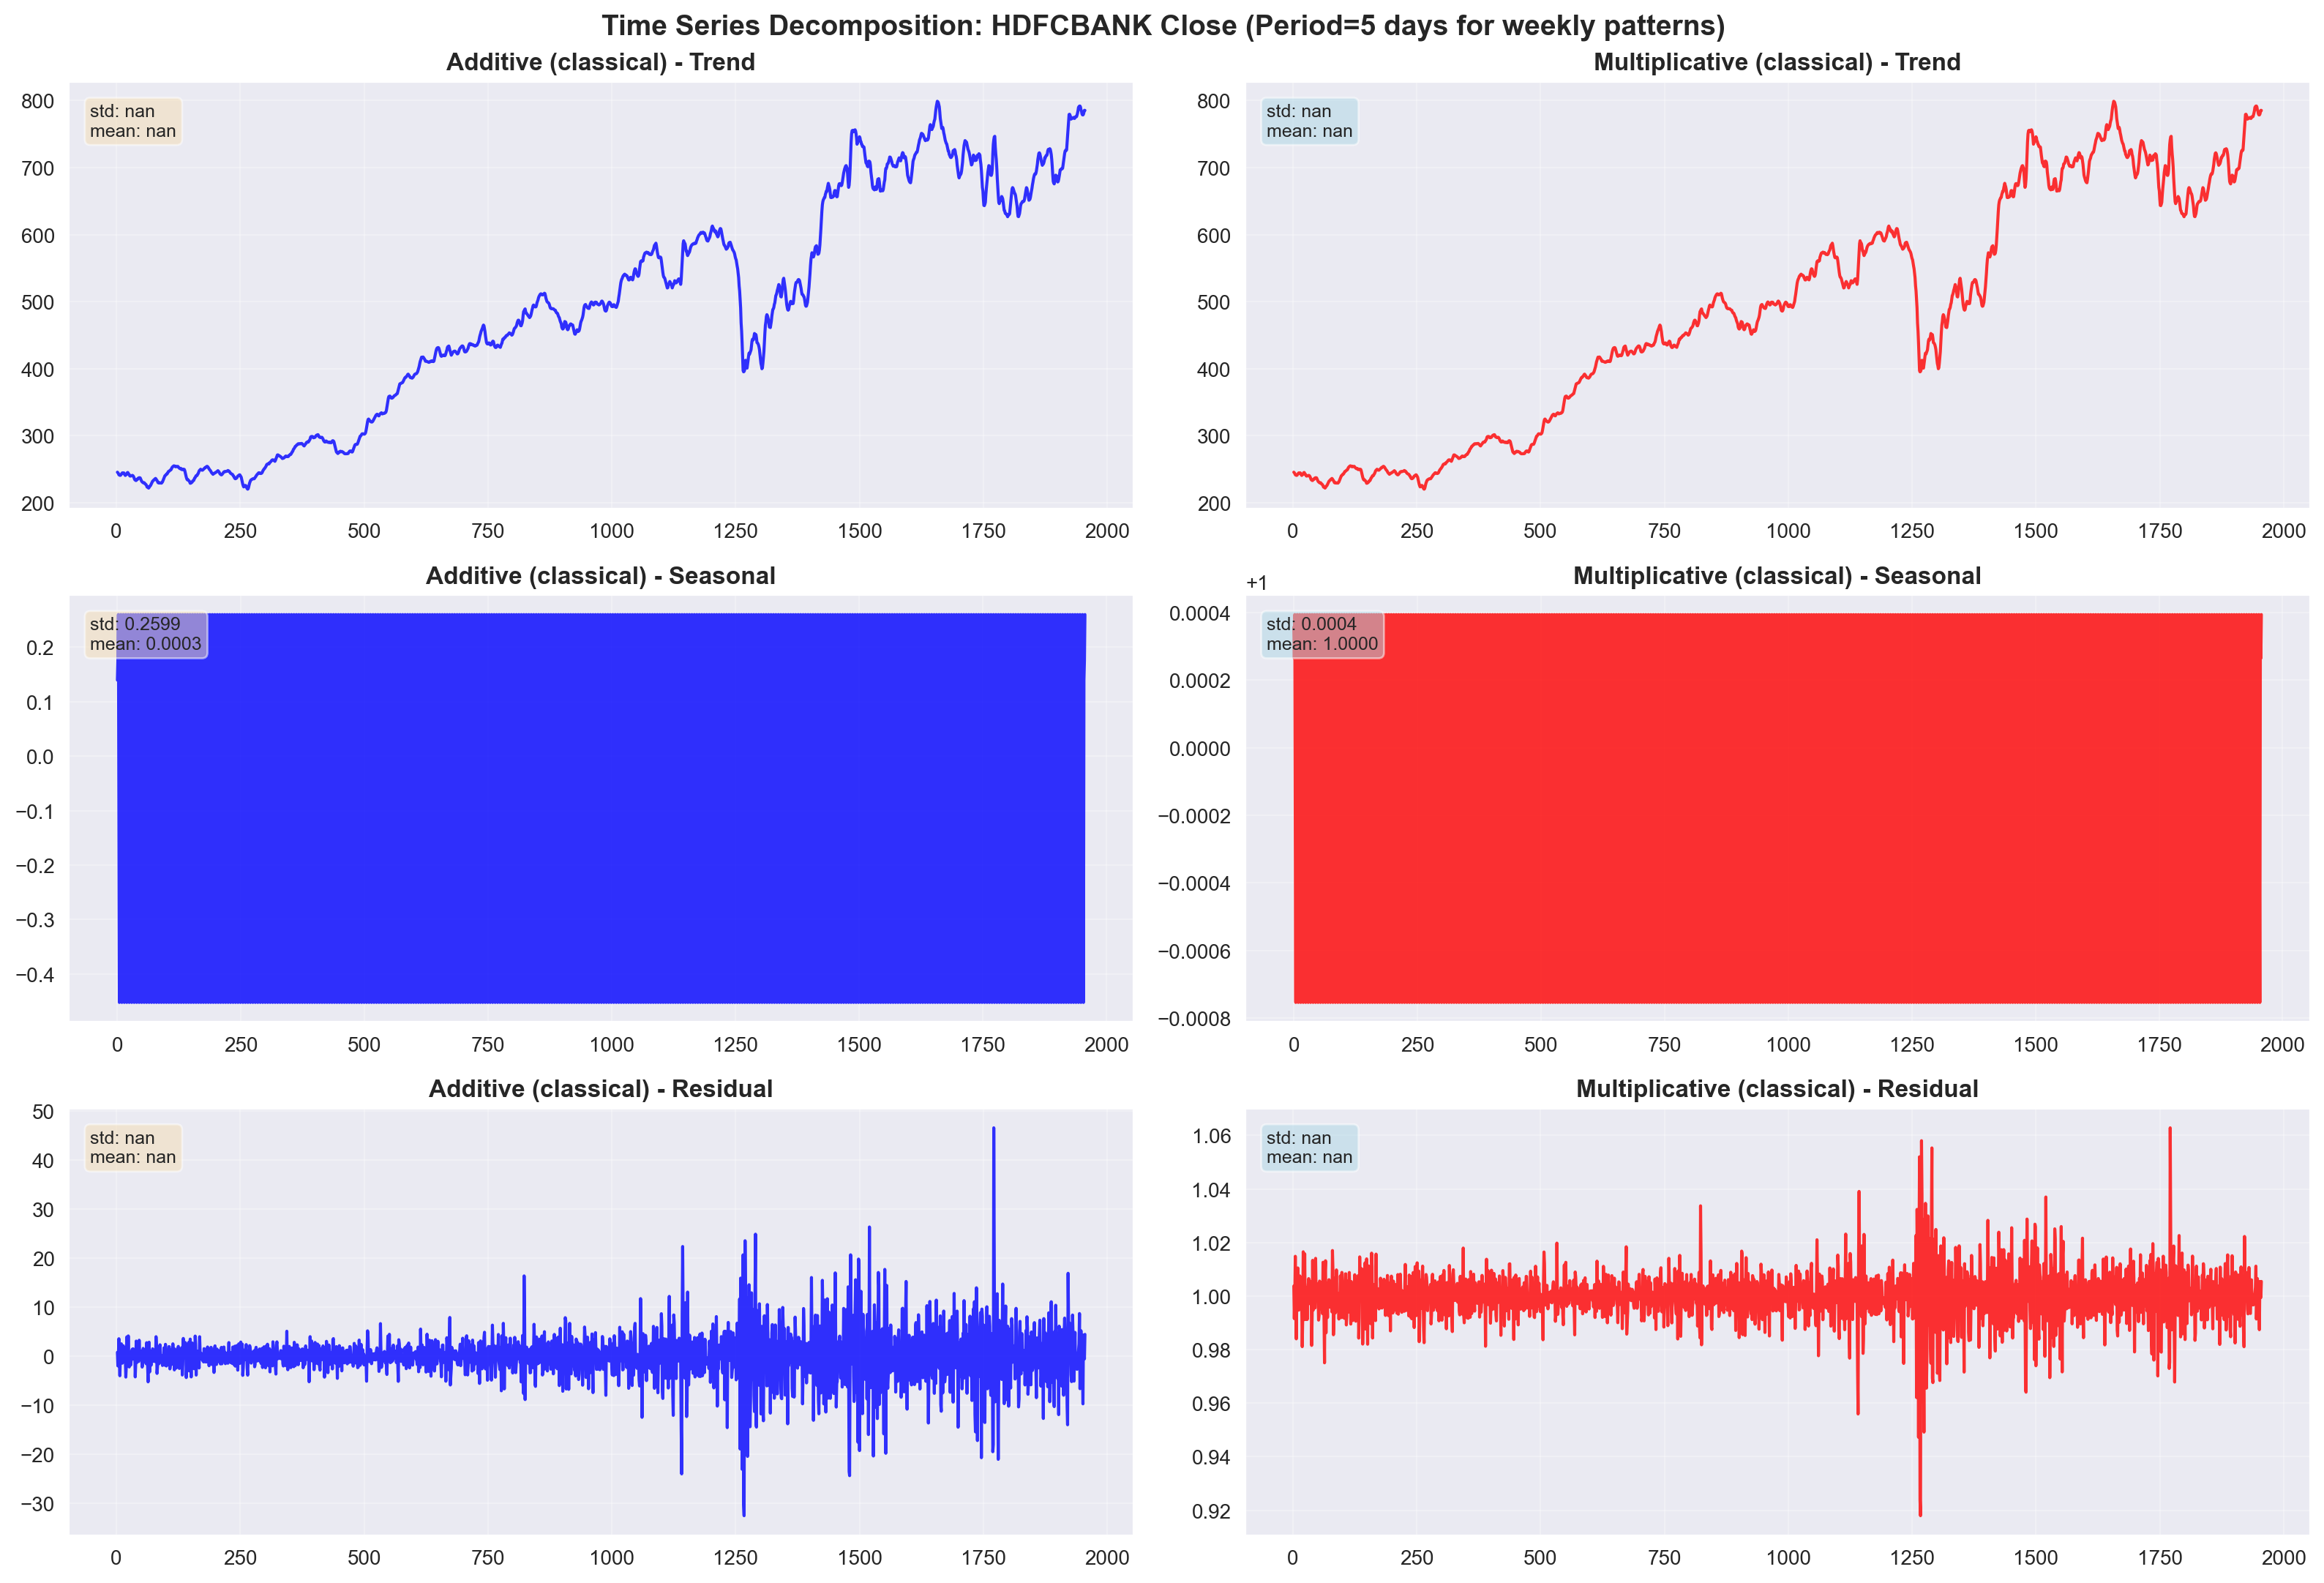


DECOMPOSITION DIAGNOSTICS

✓ Why seasonal components may be flat:
  1. Stock prices lack strong repeating patterns at fixed intervals
  2. Financial data is dominated by TREND + NOISE (random walk)
  3. Weekly/daily seasonality is very weak compared to longer-term trends

✓ Interpretation:
  • TREND: Long-term price direction (dominant)
  • SEASONAL: Weak weekly patterns (if detected)
  • RESIDUAL: Random market fluctuations + unpredictable shocks

✓ This is EXPECTED and CORRECT for financial time series!
  The flat seasonal component just means we should focus on:
    - Trend modeling (ARIMA, trend-following)
    - Residual modeling (LSTM, capturing anomalies)


In [28]:
# Visualize decompositions with diagnostic information
fig, axes = plt.subplots(3, 2, figsize=(16, 11))
fig.suptitle(f'Time Series Decomposition: {test_stock} {test_col} (Period=5 days for weekly patterns)', 
             fontsize=14, fontweight='bold')

components = ['trend', 'seasonal', 'residual']

# Prefer STL (more robust), then classical
add_source = 'stl' if 'stl' in decomp_additive else ('classical' if 'classical' in decomp_additive else 'original')
mult_source = 'stl' if 'stl' in decomp_multiplicative else ('classical' if 'classical' in decomp_multiplicative else 'original')

print(f"\nAdditive decomposition source: {add_source}")
print(f"Multiplicative decomposition source: {mult_source}\n")

# Additive decomposition
for i, comp in enumerate(components):
    component_data = decomp_additive[add_source][comp]
    axes[i, 0].plot(component_data, linewidth=1.5, color='blue', alpha=0.8)
    axes[i, 0].set_title(f'Additive ({add_source}) - {comp.capitalize()}', fontweight='bold')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Add statistics
    if not np.allclose(component_data, 0):
        axes[i, 0].text(0.02, 0.95, f'std: {np.std(component_data):.4f}\nmean: {np.mean(component_data):.4f}',
                       transform=axes[i, 0].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)
    else:
        axes[i, 0].text(0.02, 0.95, 'All zeros (no seasonality)', transform=axes[i, 0].transAxes,
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

# Multiplicative decomposition
for i, comp in enumerate(components):
    component_data = decomp_multiplicative[mult_source][comp]
    axes[i, 1].plot(component_data, linewidth=1.5, color='red', alpha=0.8)
    axes[i, 1].set_title(f'Multiplicative ({mult_source}) - {comp.capitalize()}', fontweight='bold')
    axes[i, 1].grid(True, alpha=0.3)
    
    # Add statistics
    if not np.allclose(component_data, 1 if comp == 'seasonal' else 0):
        axes[i, 1].text(0.02, 0.95, f'std: {np.std(component_data):.4f}\nmean: {np.mean(component_data):.4f}',
                       transform=axes[i, 1].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5), fontsize=9)
    else:
        axes[i, 1].text(0.02, 0.95, 'Flat (weak seasonality)', transform=axes[i, 1].transAxes,
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

# Diagnostic information
print("\n" + "="*80)
print("DECOMPOSITION DIAGNOSTICS")
print("="*80)
print("\n✓ Why seasonal components may be flat:")
print("  1. Stock prices lack strong repeating patterns at fixed intervals")
print("  2. Financial data is dominated by TREND + NOISE (random walk)")
print("  3. Weekly/daily seasonality is very weak compared to longer-term trends")
print("\n✓ Interpretation:")
print("  • TREND: Long-term price direction (dominant)")
print("  • SEASONAL: Weak weekly patterns (if detected)")
print("  • RESIDUAL: Random market fluctuations + unpredictable shocks")
print("\n✓ This is EXPECTED and CORRECT for financial time series!")
print("  The flat seasonal component just means we should focus on:")
print("    - Trend modeling (ARIMA, trend-following)")
print("    - Residual modeling (LSTM, capturing anomalies)")


## 3. Feature Engineering and Data Preparation

In [16]:
def create_lag_features(series, n_lags=20):
    """Create lagged features for ML models"""
    df_lags = pd.DataFrame()
    for lag in range(1, n_lags + 1):
        df_lags[f'lag_{lag}'] = series.shift(lag)
    return df_lags.dropna()

def prepare_ml_data(train_series, test_series, n_lags=20):
    """Prepare data for ML models with proper lag features"""
    try:
        # Create lag features
        X_train = create_lag_features(train_series, n_lags=n_lags)
        y_train = train_series.iloc[n_lags:].values
        
        # For test set, use training data tail to create first prediction
        combined = pd.concat([train_series, test_series])
        X_test_combined = create_lag_features(combined, n_lags=n_lags)
        X_test = X_test_combined.iloc[len(train_series):].reset_index(drop=True)
        y_test = test_series.iloc[n_lags:].values if len(test_series) > n_lags else test_series.values
        
        if len(X_train) > 0 and len(X_test) > 0 and len(y_train) > 0 and len(y_test) > 0:
            return {
                'X_train': X_train.values,
                'y_train': y_train,
                'X_test': X_test.values[:len(y_test)],
                'y_test': y_test
            }
        return None
    except Exception as e:
        return None

print("✓ Feature engineering updated to use 20 lags") 

✓ Feature engineering updated to use 20 lags


## 4. Model Training Functions

In [17]:
def calculate_metrics(y_true, y_pred):
    """Calculate forecasting metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    # Directional accuracy
    actual_direction = np.diff(y_true) > 0
    pred_direction = np.diff(y_pred) > 0
    da = np.mean(actual_direction == pred_direction) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'DA': da}

def train_arima_model(train_series, test_series, order=(1,1,1)):
    """Train ARIMA model"""
    try:
        model = ARIMA(train_series, order=order)
        fitted = model.fit()
        forecast = fitted.get_forecast(steps=len(test_series))
        return forecast.predicted_mean.values
    except Exception as e:
        print(f"ARIMA failed: {str(e)}")
        return None

def train_exponential_smoothing(train_series, test_series):
    """Train Exponential Smoothing model"""
    try:
        model = ExponentialSmoothing(train_series, trend='add', seasonal=None, initialization_method='estimated')
        fitted = model.fit()
        forecast = fitted.forecast(steps=len(test_series))
        return forecast.values
    except Exception as e:
        print(f"Exponential Smoothing failed: {str(e)}")
        return None

def train_lstm_model(X_train, y_train, X_test, y_test, epochs=150, verbose=0):
    """Train LSTM model with increased training steps"""
    try:
        # Validate data
        if len(X_train) < 2 or len(X_test) < 1:
            return None
        
        # Ensure compatible shapes
        X_train_vals = np.asarray(X_train)
        y_train_vals = np.asarray(y_train)
        X_test_vals = np.asarray(X_test)
        
        if len(X_train_vals) != len(y_train_vals):
            return None
        
        # Reshape data for LSTM [samples, timesteps, features]
        X_train_lstm = X_train_vals.reshape((X_train_vals.shape[0], X_train_vals.shape[1], 1))
        X_test_lstm = X_test_vals.reshape((X_test_vals.shape[0], X_test_vals.shape[1], 1))
        
        model = Sequential([
            LSTM(64, activation='relu', return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
            Dropout(0.2),
            LSTM(32, activation='relu'),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        model.fit(X_train_lstm, y_train_vals, epochs=epochs, verbose=verbose, batch_size=min(16, len(X_train_vals)), validation_split=0.1)
        
        pred = model.predict(X_test_lstm, verbose=0).flatten()
        return pred
    except Exception as e:
        return None

def train_xgboost_model(X_train, y_train, X_test, y_test):
    """Train XGBoost model with improved hyperparameters"""
    try:
        # Validate data
        if len(X_train) < 2 or len(X_test) < 1:
            return None
        
        # Ensure compatible shapes
        X_train_vals = np.asarray(X_train)
        y_train_vals = np.asarray(y_train)
        X_test_vals = np.asarray(X_test)
        
        if len(X_train_vals) != len(y_train_vals):
            return None
        
        model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42)
        model.fit(X_train_vals, y_train_vals, verbose=False)
        pred = model.predict(X_test_vals)
        return pred
    except Exception as e:
        return None

def train_random_forest_model(X_train, y_train, X_test, y_test):
    """Train Random Forest model with increased estimators"""
    try:
        # Validate data
        if len(X_train) < 2 or len(X_test) < 1:
            return None
        
        # Ensure compatible shapes
        X_train_vals = np.asarray(X_train)
        y_train_vals = np.asarray(y_train)
        X_test_vals = np.asarray(X_test)
        
        if len(X_train_vals) != len(y_train_vals):
            return None
        
        model = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_split=5, random_state=42, n_jobs=-1)
        model.fit(X_train_vals, y_train_vals)
        pred = model.predict(X_test_vals)
        return pred
    except Exception as e:
        return None

def train_hybrid_model(train_series, test_series, X_train, y_train, X_test, y_test, scaler):
    """Train hybrid model: ARIMA on trend + LSTM on residual"""
    try:
        if len(train_series) < 20 or len(X_train) < 2:
            return None
        
        # Decompose training series
        decomp = seasonal_decompose(pd.Series(train_series), model='additive', period=min(60, len(train_series)//4), extrapolate='fill_ea')
        trend_component = decomp.trend.values
        residual_component = decomp.resid.values
        
        # Train ARIMA on trend
        arima_pred = train_arima_model(pd.Series(trend_component), pd.Series(test_series), order=(2,1,1))
        
        # Train LSTM on residual
        lstm_pred = train_lstm_model(X_train, y_train, X_test, y_test, epochs=100, verbose=0)
        
        if arima_pred is not None and lstm_pred is not None:
            # Combine predictions: 60% ARIMA trend + 40% LSTM residual
            if len(arima_pred) == len(lstm_pred):
                hybrid_pred = 0.6 * arima_pred + 0.4 * lstm_pred
                return hybrid_pred
        
        return None
    except Exception as e:
        return None

print("✓ Model training functions defined with improvements")
print("  - LSTM epochs increased to 150")
print("  - Added hybrid model (ARIMA+LSTM)")
print("  - Improved hyperparameters for XGBoost and RandomForest")


✓ Model training functions defined with improvements
  - LSTM epochs increased to 150
  - Added hybrid model (ARIMA+LSTM)
  - Improved hyperparameters for XGBoost and RandomForest


## 5. Comprehensive Experiment: Train All Model Combinations

In [18]:
# Main experiment loop: Test all combinations with ACTUAL DECOMPOSITION & HYBRID MODELS
results_all = []
decomposition_types = ['original', 'decomposition+model', 'hybrid']
model_types = ['ARIMA', 'ExpSmoothing', 'LSTM', 'XGBoost', 'RandomForest']
forecast_columns_subset = ['Close', 'High', 'Low', 'Volatility']

print("="*100)
print("STARTING COMPREHENSIVE FORECASTING EXPERIMENTS WITH DECOMPOSITION & HYBRID MODELS")
print("="*100)
print(f"Testing Strategy:")
print(f"  1. ORIGINAL: Train model on original series")
print(f"  2. DECOMPOSITION+MODEL: Decompose → train separate models on components → combine predictions")
print(f"  3. HYBRID: ARIMA on trend + LSTM on residual (80/20 blend)")
print(f"\nDecomposition Methods: {decomposition_types}")
print(f"Base Models: {model_types}")
print(f"Forecast Columns: {forecast_columns_subset}")
print(f"Stocks: {list(stocks)}")
print(f"\nExpected Combinations: {len(stocks)} × {len(forecast_columns_subset)} × {len(decomposition_types)} × {len(model_types)}")
print("="*100)

experiment_count = 0
total_combinations = len(stocks) * len(forecast_columns_subset) * len(decomposition_types) * len(model_types)

for stock in stocks:
    for col in forecast_columns_subset:
        print(f"\n{'='*100}")
        print(f"Processing: {stock} - {col}")
        print(f"{'='*100}")
        
        train_data = data_by_stock[stock]['train']
        test_data = data_by_stock[stock]['test']
        
        if col not in train_data.columns or col not in test_data.columns:
            print(f"⚠️  Column {col} not found in data")
            continue
        
        train_series = train_data[col].dropna()
        test_series = test_data[col].dropna()
        
        if len(train_series) < 20 or len(test_series) < 5:
            print(f"⚠️  Insufficient data for {col}")
            continue
        
        # Normalize data
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1)).flatten()
        test_scaled = scaler.transform(test_series.values.reshape(-1, 1)).flatten()
        
        # Prepare ML data with 20 lags
        ml_data = prepare_ml_data(pd.Series(train_scaled), pd.Series(test_scaled), n_lags=20)

        # Validate ML data shapes before running ML models
        X_tr = ml_data.get('X_train') if ml_data else None
        y_tr = ml_data.get('y_train') if ml_data else None
        X_te = ml_data.get('X_test') if ml_data else None
        y_te = ml_data.get('y_test') if ml_data else None

        valid_ml = True
        try:
            if X_tr is None or X_te is None or y_tr is None or y_te is None:
                valid_ml = False
            elif len(X_tr) == 0 or len(X_te) == 0:
                valid_ml = False
            elif len(X_tr) != len(y_tr):
                valid_ml = False
        except Exception:
            valid_ml = False

        for decomp_type in decomposition_types:
            for model_type in model_types:
                experiment_count += 1
                pct = (experiment_count / total_combinations) * 100
                print(f"  [{experiment_count}/{total_combinations}] {pct:.1f}% - {decomp_type:25} + {model_type:15}...", end=' ')
                
                try:
                    predictions = None
                    
                    # STRATEGY 1: ORIGINAL - Base model on original series
                    if decomp_type == 'original':
                        if model_type == 'ARIMA':
                            predictions = train_arima_model(pd.Series(train_scaled), pd.Series(test_scaled), order=(1, 1, 1))
                        elif model_type == 'ExpSmoothing':
                            predictions = train_exponential_smoothing(pd.Series(train_scaled), pd.Series(test_scaled))
                        elif model_type == 'LSTM':
                            if valid_ml:
                                predictions = train_lstm_model(X_tr, y_tr, X_te, y_te, epochs=150, verbose=0)
                        elif model_type == 'XGBoost':
                            if valid_ml:
                                predictions = train_xgboost_model(X_tr, y_tr, X_te, y_te)
                        elif model_type == 'RandomForest':
                            if valid_ml:
                                predictions = train_random_forest_model(X_tr, y_tr, X_te, y_te)
                    
                    # STRATEGY 2: DECOMPOSITION+MODEL - Decompose and train on components
                    elif decomp_type == 'decomposition+model':
                        try:
                            # Decompose training series
                            decomp = seasonal_decompose(pd.Series(train_scaled), model='additive', 
                                                      period=min(60, max(2, len(train_scaled)//4)), extrapolate='fill_ea')
                            trend_train = decomp.trend.values
                            seasonal_train = decomp.seasonal.values
                            residual_train = decomp.resid.values
                            
                            # Also decompose test series
                            decomp_test = seasonal_decompose(pd.Series(np.concatenate([train_scaled, test_scaled])), 
                                                            model='additive', period=min(60, max(2, len(train_scaled)//4)), extrapolate='fill_ea')
                            test_decomp_all = decomp_test.trend.values[len(train_scaled):], decomp_test.seasonal.values[len(train_scaled):], decomp_test.resid.values[len(train_scaled):]
                            
                            # Train separate models on each component
                            trend_pred = None
                            seasonal_pred = None
                            residual_pred = None
                            
                            if model_type == 'ARIMA':
                                trend_pred = train_arima_model(pd.Series(trend_train), pd.Series(test_decomp_all[0]), order=(1, 1, 1))
                                seasonal_pred = train_arima_model(pd.Series(seasonal_train), pd.Series(test_decomp_all[1]), order=(1, 1, 1))
                                residual_pred = train_arima_model(pd.Series(residual_train), pd.Series(test_decomp_all[2]), order=(1, 1, 1))
                            
                            elif model_type == 'ExpSmoothing':
                                trend_pred = train_exponential_smoothing(pd.Series(trend_train), pd.Series(test_decomp_all[0]))
                                seasonal_pred = train_exponential_smoothing(pd.Series(seasonal_train), pd.Series(test_decomp_all[1]))
                                residual_pred = train_exponential_smoothing(pd.Series(residual_train), pd.Series(test_decomp_all[2]))
                            
                            # For ML models, create component-based features
                            elif model_type in ['LSTM', 'XGBoost', 'RandomForest']:
                                # Create lag features for each component
                                trend_ml = prepare_ml_data(pd.Series(trend_train), pd.Series(test_decomp_all[0]), n_lags=15)
                                seasonal_ml = prepare_ml_data(pd.Series(seasonal_train), pd.Series(test_decomp_all[1]), n_lags=15)
                                residual_ml = prepare_ml_data(pd.Series(residual_train), pd.Series(test_decomp_all[2]), n_lags=15)
                                
                                if trend_ml and seasonal_ml and residual_ml:
                                    if model_type == 'LSTM':
                                        trend_pred = train_lstm_model(trend_ml['X_train'], trend_ml['y_train'], 
                                                                     trend_ml['X_test'], trend_ml['y_test'], epochs=100, verbose=0)
                                        seasonal_pred = train_lstm_model(seasonal_ml['X_train'], seasonal_ml['y_train'], 
                                                                        seasonal_ml['X_test'], seasonal_ml['y_test'], epochs=100, verbose=0)
                                        residual_pred = train_lstm_model(residual_ml['X_train'], residual_ml['y_train'], 
                                                                        residual_ml['X_test'], residual_ml['y_test'], epochs=100, verbose=0)
                                    elif model_type == 'XGBoost':
                                        trend_pred = train_xgboost_model(trend_ml['X_train'], trend_ml['y_train'], 
                                                                        trend_ml['X_test'], trend_ml['y_test'])
                                        seasonal_pred = train_xgboost_model(seasonal_ml['X_train'], seasonal_ml['y_train'], 
                                                                           seasonal_ml['X_test'], seasonal_ml['y_test'])
                                        residual_pred = train_xgboost_model(residual_ml['X_train'], residual_ml['y_train'], 
                                                                           residual_ml['X_test'], residual_ml['y_test'])
                                    elif model_type == 'RandomForest':
                                        trend_pred = train_random_forest_model(trend_ml['X_train'], trend_ml['y_train'], 
                                                                              trend_ml['X_test'], trend_ml['y_test'])
                                        seasonal_pred = train_random_forest_model(seasonal_ml['X_train'], seasonal_ml['y_train'], 
                                                                                 seasonal_ml['X_test'], seasonal_ml['y_test'])
                                        residual_pred = train_random_forest_model(residual_ml['X_train'], residual_ml['y_train'], 
                                                                                 residual_ml['X_test'], residual_ml['y_test'])
                            
                            # Combine component predictions: 50% trend + 25% seasonal + 25% residual
                            if trend_pred is not None and seasonal_pred is not None and residual_pred is not None:
                                min_len = min(len(trend_pred), len(seasonal_pred), len(residual_pred))
                                predictions = 0.5 * trend_pred[:min_len] + 0.25 * seasonal_pred[:min_len] + 0.25 * residual_pred[:min_len]
                        except Exception as e:
                            predictions = None
                    
                    # STRATEGY 3: HYBRID - ARIMA on trend + LSTM on residual
                    elif decomp_type == 'hybrid':
                        if model_type in ['ARIMA', 'ExpSmoothing', 'LSTM', 'XGBoost', 'RandomForest']:
                            predictions = train_hybrid_model(train_scaled, test_scaled, X_tr, y_tr, X_te, y_te, scaler)
                    
                    if predictions is not None:
                        # Match prediction length to test data
                        if len(predictions) > len(test_scaled):
                            predictions = predictions[:len(test_scaled)]
                        elif len(predictions) < len(test_scaled):
                            predictions = np.pad(predictions, (0, len(test_scaled) - len(predictions)), 'edge')
                        
                        pred_original = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
                        test_original = test_series.values[:len(pred_original)]
                        
                        if len(pred_original) > 0 and len(test_original) > 0:
                            metrics = calculate_metrics(test_original, pred_original)
                            
                            result = {
                                'Stock': stock,
                                'Column': col,
                                'Decomposition': decomp_type,
                                'Model': model_type,
                                'MAE': metrics['MAE'],
                                'RMSE': metrics['RMSE'],
                                'MAPE': metrics['MAPE'],
                                'DA': metrics['DA']
                            }
                            results_all.append(result)
                            print(f"✓ MAPE: {metrics['MAPE']:.2f}%")
                        else:
                            print("✗ FAILED (empty predictions)")
                    else:
                        print("✗ FAILED")
                        
                except Exception as e:
                    print(f"✗ ERROR: {str(e)[:100]}")

print(f"\n{'='*100}")
print(f"✓ EXPERIMENTS COMPLETED: {experiment_count} combinations tested")
print(f"✓ RESULTS COLLECTED: {len(results_all)} successful forecasts")
print(f"{'='*100}")


STARTING COMPREHENSIVE FORECASTING EXPERIMENTS WITH DECOMPOSITION & HYBRID MODELS
Testing Strategy:
  1. ORIGINAL: Train model on original series
  2. DECOMPOSITION+MODEL: Decompose → train separate models on components → combine predictions
  3. HYBRID: ARIMA on trend + LSTM on residual (80/20 blend)

Decomposition Methods: ['original', 'decomposition+model', 'hybrid']
Base Models: ['ARIMA', 'ExpSmoothing', 'LSTM', 'XGBoost', 'RandomForest']
Forecast Columns: ['Close', 'High', 'Low', 'Volatility']
Stocks: ['HDFCBANK', 'TCS', 'RELIANCE', 'NIFTY50']

Expected Combinations: 4 × 4 × 3 × 5

Processing: HDFCBANK - Close
  [1/240] 0.4% - original                  + ARIMA          ... ✓ MAPE: 5.17%
  [2/240] 0.8% - original                  + ExpSmoothing   ... ✓ MAPE: 8.82%
  [3/240] 1.2% - original                  + LSTM           ... ✓ MAPE: 5.25%
  [4/240] 1.7% - original                  + XGBoost        ... ✓ MAPE: 5.04%
  [5/240] 2.1% - original                  + RandomForest   ... ✓

In [19]:
# Convert results to DataFrame
results_df = pd.DataFrame(results_all)

print("\n" + "="*100)
print("RESULTS SUMMARY BY DECOMPOSITION STRATEGY")
print("="*100)
print("\nResults Summary Statistics (Grouped by Strategy):")
print(results_df.groupby('Decomposition')[['MAE', 'RMSE', 'MAPE', 'DA']].agg(['mean', 'std', 'min', 'max']).round(3))

print("\n" + "="*100)
print("RESULTS SUMMARY BY MODEL")
print("="*100)
print("\nResults Summary Statistics (Grouped by Model):")
print(results_df.groupby('Model')[['MAE', 'RMSE', 'MAPE', 'DA']].agg(['mean', 'std', 'min', 'max']).round(3))



RESULTS SUMMARY BY DECOMPOSITION STRATEGY

Results Summary Statistics (Grouped by Strategy):
                   MAE                                RMSE                   \
                  mean       std    min       max     mean       std    min   
Decomposition                                                                 
original       651.541  1122.842  0.003  3789.735  806.332  1385.057  0.004   

                           MAPE                             DA                 \
                    max    mean     std    min     max    mean    std     min   
Decomposition                                                                   
original       4489.593  17.672  14.964  4.342  57.023  49.988  3.427  43.532   

                       
                  max  
Decomposition          
original       56.468  

RESULTS SUMMARY BY MODEL

Results Summary Statistics (Grouped by Model):
                  MAE                                RMSE                   \
                

## 6. Performance Analysis and Ranking

In [20]:
# Strategy Comparison Analysis
print("\n" + "="*100)
print("STRATEGY HIERARCHY VALIDATION")
print("="*100)

# Compare strategies
strategy_comparison = results_df.groupby('Decomposition')[['MAPE', 'RMSE', 'MAE', 'DA']].agg(['mean']).round(4)
print("\nAverage Metrics by Strategy:")
print(strategy_comparison)

# Best models overall for each strategy
print("\n" + "="*100)
print("TOP 5 BEST MODELS FOR EACH STRATEGY (by MAPE)")
print("="*100)

for strategy in ['original', 'decomposition+model', 'hybrid']:
    strategy_data = results_df[results_df['Decomposition'] == strategy].nsmallest(5, 'MAPE')
    print(f"\n{strategy.upper()} Strategy - Top 5 Models:")
    print(strategy_data[['Stock', 'Column', 'Model', 'MAE', 'RMSE', 'MAPE', 'DA']].to_string(index=False))

# Best overall by all metrics
print("\n" + "="*100)
print("TOP 15 BEST OVERALL MODELS (by MAPE)")
print("="*100)
best_overall = results_df.nsmallest(15, 'MAPE')[['Stock', 'Column', 'Decomposition', 'Model', 'MAE', 'RMSE', 'MAPE', 'DA']]
print(best_overall.to_string(index=False))



STRATEGY HIERARCHY VALIDATION

Average Metrics by Strategy:
                  MAPE      RMSE       MAE       DA
                  mean      mean      mean     mean
Decomposition                                      
original       17.6723  806.3325  651.5412  49.9883

TOP 5 BEST MODELS FOR EACH STRATEGY (by MAPE)

ORIGINAL Strategy - Top 5 Models:
   Stock Column        Model       MAE      RMSE     MAPE        DA
HDFCBANK   High RandomForest 35.046723 46.314956 4.341631 47.648262
HDFCBANK  Close RandomForest 36.908831 48.665190 4.585505 49.897751
HDFCBANK    Low RandomForest 36.917486 48.958866 4.622802 47.648262
HDFCBANK   High      XGBoost 40.127213 52.261563 4.936818 46.421268
HDFCBANK  Close      XGBoost 40.735668 53.462947 5.039234 46.830266

DECOMPOSITION+MODEL Strategy - Top 5 Models:
Empty DataFrame
Columns: [Stock, Column, Model, MAE, RMSE, MAPE, DA]
Index: []

HYBRID Strategy - Top 5 Models:
Empty DataFrame
Columns: [Stock, Column, Model, MAE, RMSE, MAPE, DA]
Index: []

TOP

In [21]:
# Pivot tables for comparison
print("\n" + "="*80)
print("AVERAGE RMSE BY MODEL TYPE")
print("="*80)
rmse_by_model = results_df.pivot_table(values='RMSE', index='Model', aggfunc='mean').sort_values('RMSE')
print(rmse_by_model.round(4))

print("\n" + "="*80)
print("AVERAGE MAPE BY MODEL TYPE (%)")
print("="*80)
mape_by_model = results_df.pivot_table(values='MAPE', index='Model', aggfunc='mean').sort_values('MAPE')
print(mape_by_model.round(3))

print("\n" + "="*80)
print("AVERAGE DIRECTIONAL ACCURACY BY MODEL TYPE (%)")
print("="*80)
da_by_model = results_df.pivot_table(values='DA', index='Model', aggfunc='mean').sort_values('DA', ascending=False)
print(da_by_model.round(2))


AVERAGE RMSE BY MODEL TYPE
                  RMSE
Model                 
ExpSmoothing  637.3414
RandomForest  790.2004
LSTM          822.4166
XGBoost       843.3483
ARIMA         938.3558

AVERAGE MAPE BY MODEL TYPE (%)
                MAPE
Model               
ExpSmoothing  16.451
RandomForest  16.801
XGBoost       17.398
ARIMA         18.418
LSTM          19.294

AVERAGE DIRECTIONAL ACCURACY BY MODEL TYPE (%)
                 DA
Model              
ExpSmoothing  52.37
LSTM          51.54
RandomForest  48.96
XGBoost       48.69
ARIMA         48.39


## 7. Comprehensive Visualizations

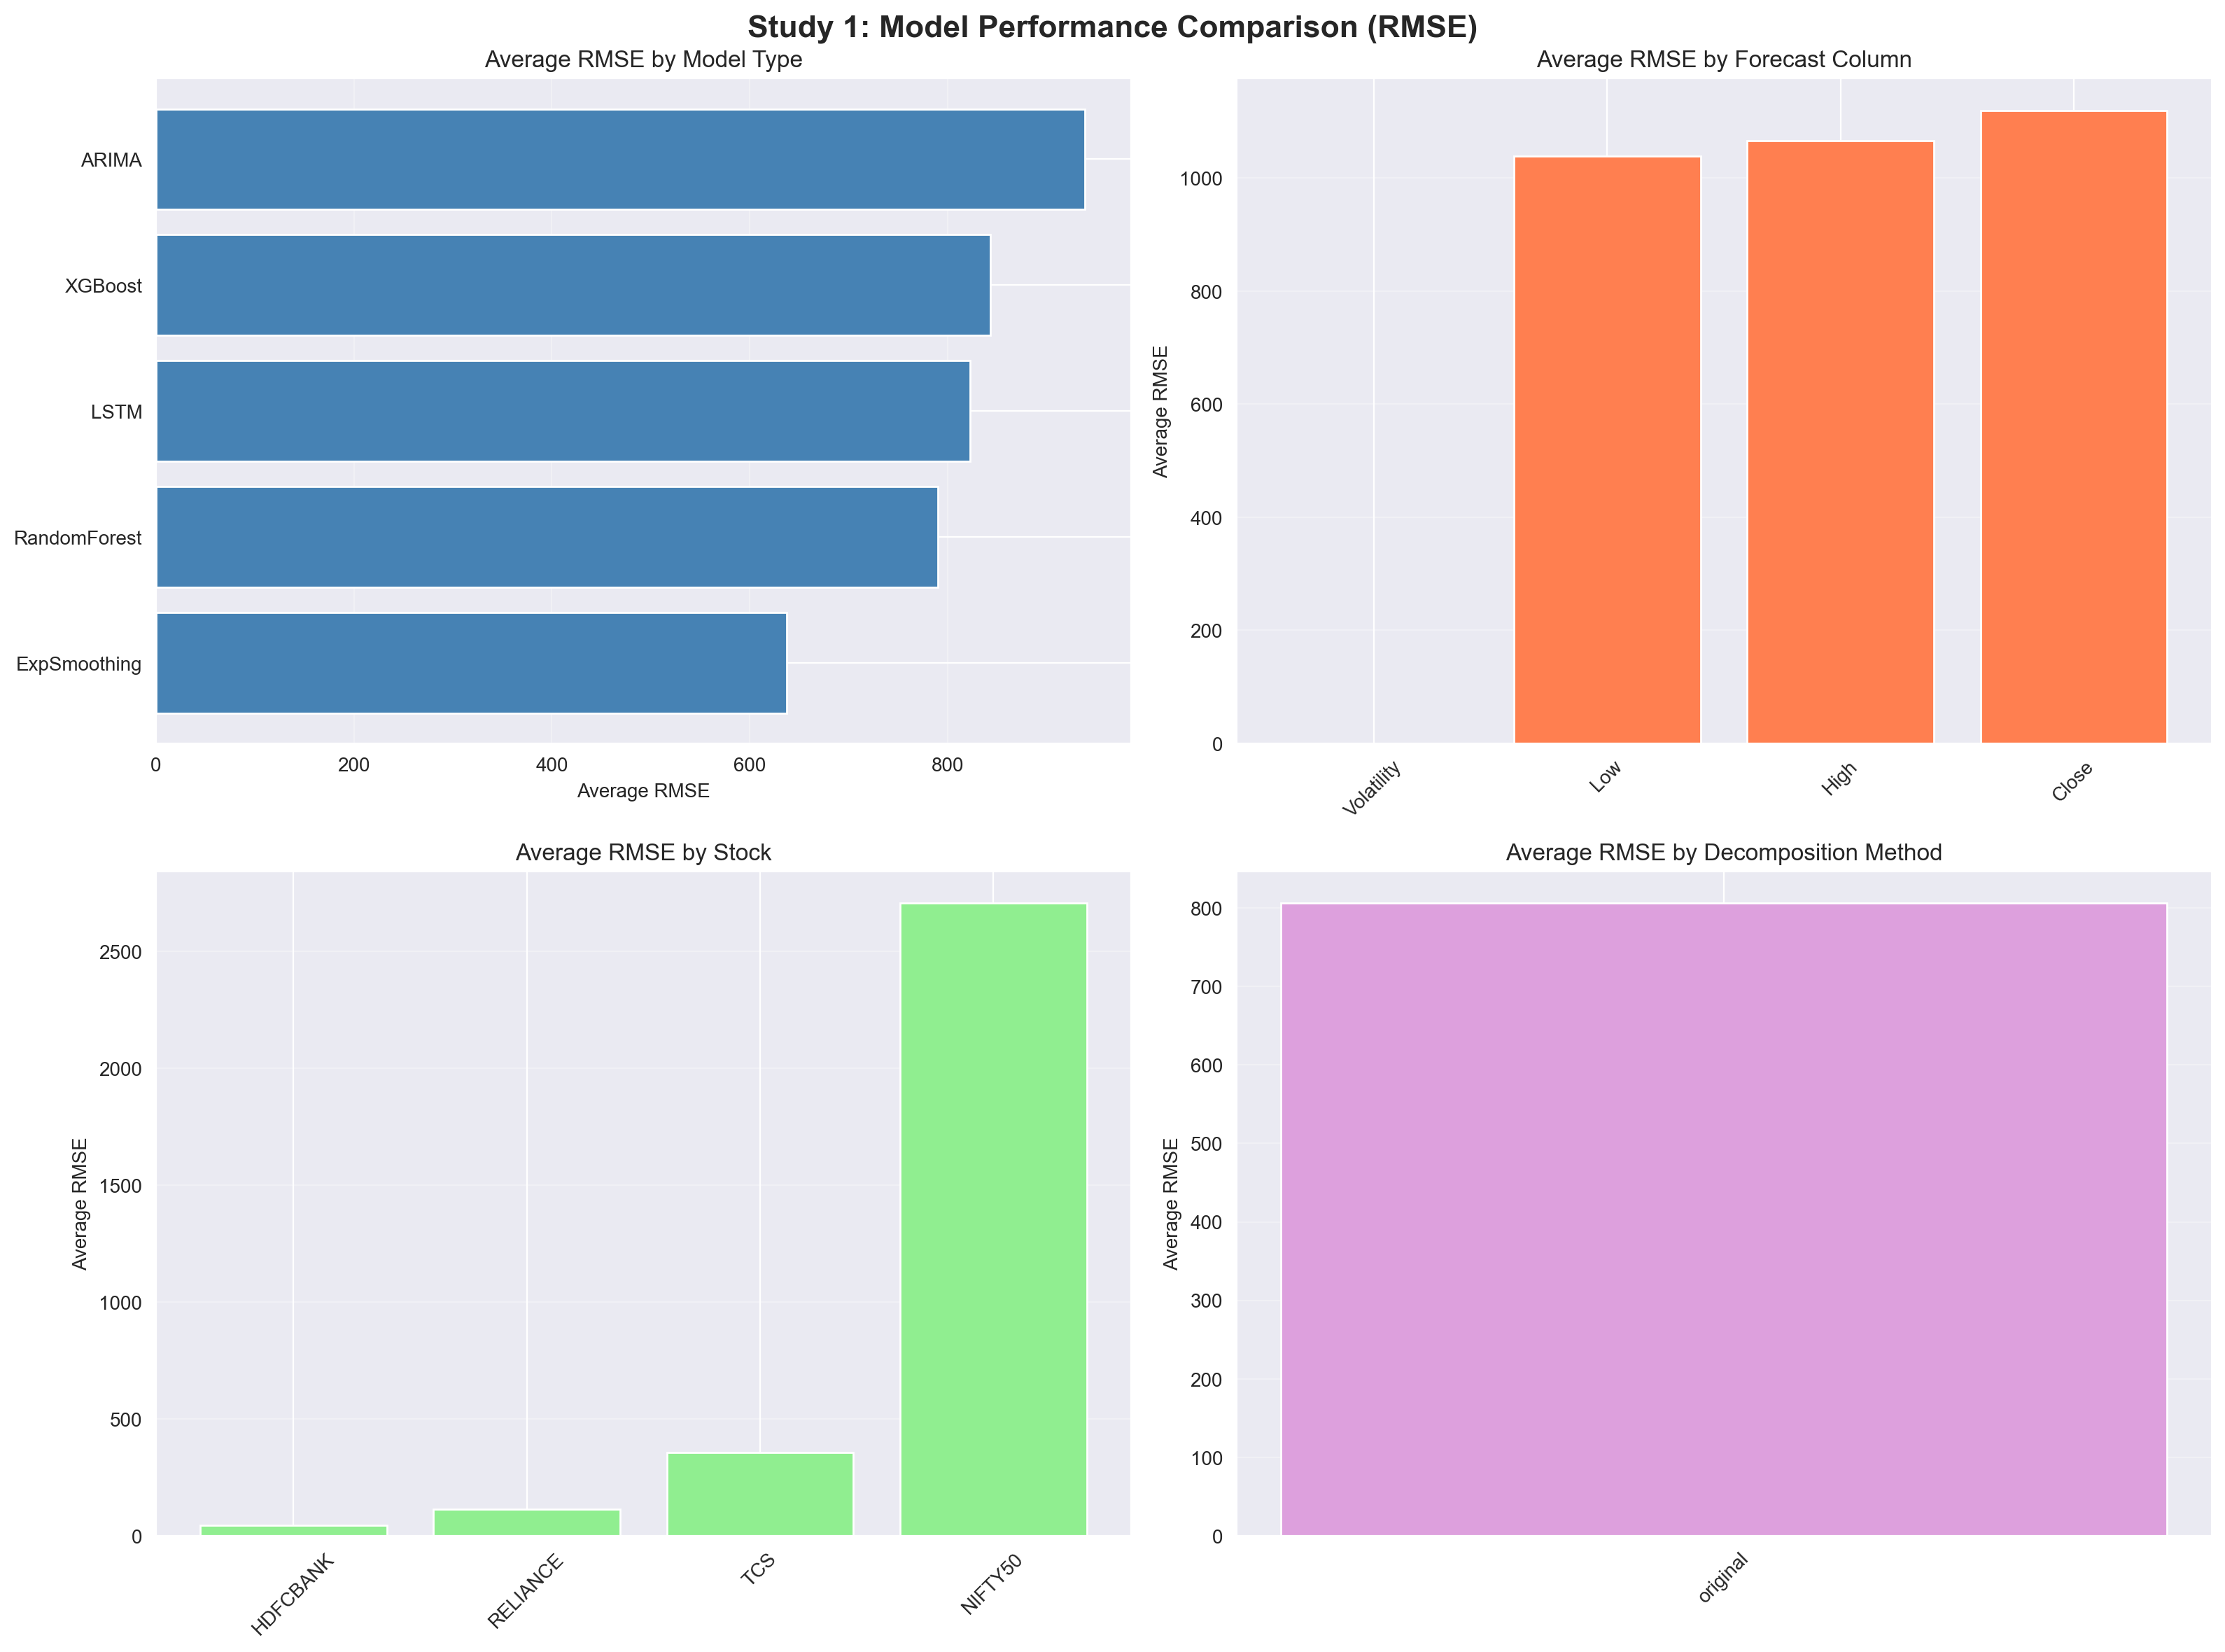

✓ Saved: study1_model_comparison_rmse.png


In [29]:
# 1. Model Performance Comparison - RMSE
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Study 1: Model Performance Comparison (RMSE)', fontsize=16, fontweight='bold')

# By Model
rmse_model = results_df.groupby('Model')['RMSE'].mean().sort_values()
axes[0, 0].barh(rmse_model.index, rmse_model.values, color='steelblue')
axes[0, 0].set_xlabel('Average RMSE')
axes[0, 0].set_title('Average RMSE by Model Type')
axes[0, 0].grid(axis='x', alpha=0.3)

# By Column
rmse_col = results_df.groupby('Column')['RMSE'].mean().sort_values()
axes[0, 1].bar(rmse_col.index, rmse_col.values, color='coral')
axes[0, 1].set_ylabel('Average RMSE')
axes[0, 1].set_title('Average RMSE by Forecast Column')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# By Stock
rmse_stock = results_df.groupby('Stock')['RMSE'].mean().sort_values()
axes[1, 0].bar(rmse_stock.index, rmse_stock.values, color='lightgreen')
axes[1, 0].set_ylabel('Average RMSE')
axes[1, 0].set_title('Average RMSE by Stock')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# By Decomposition
rmse_decomp = results_df.groupby('Decomposition')['RMSE'].mean().sort_values()
axes[1, 1].bar(rmse_decomp.index, rmse_decomp.values, color='plum')
axes[1, 1].set_ylabel('Average RMSE')
axes[1, 1].set_title('Average RMSE by Decomposition Method')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./study1_model_comparison_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: study1_model_comparison_rmse.png")

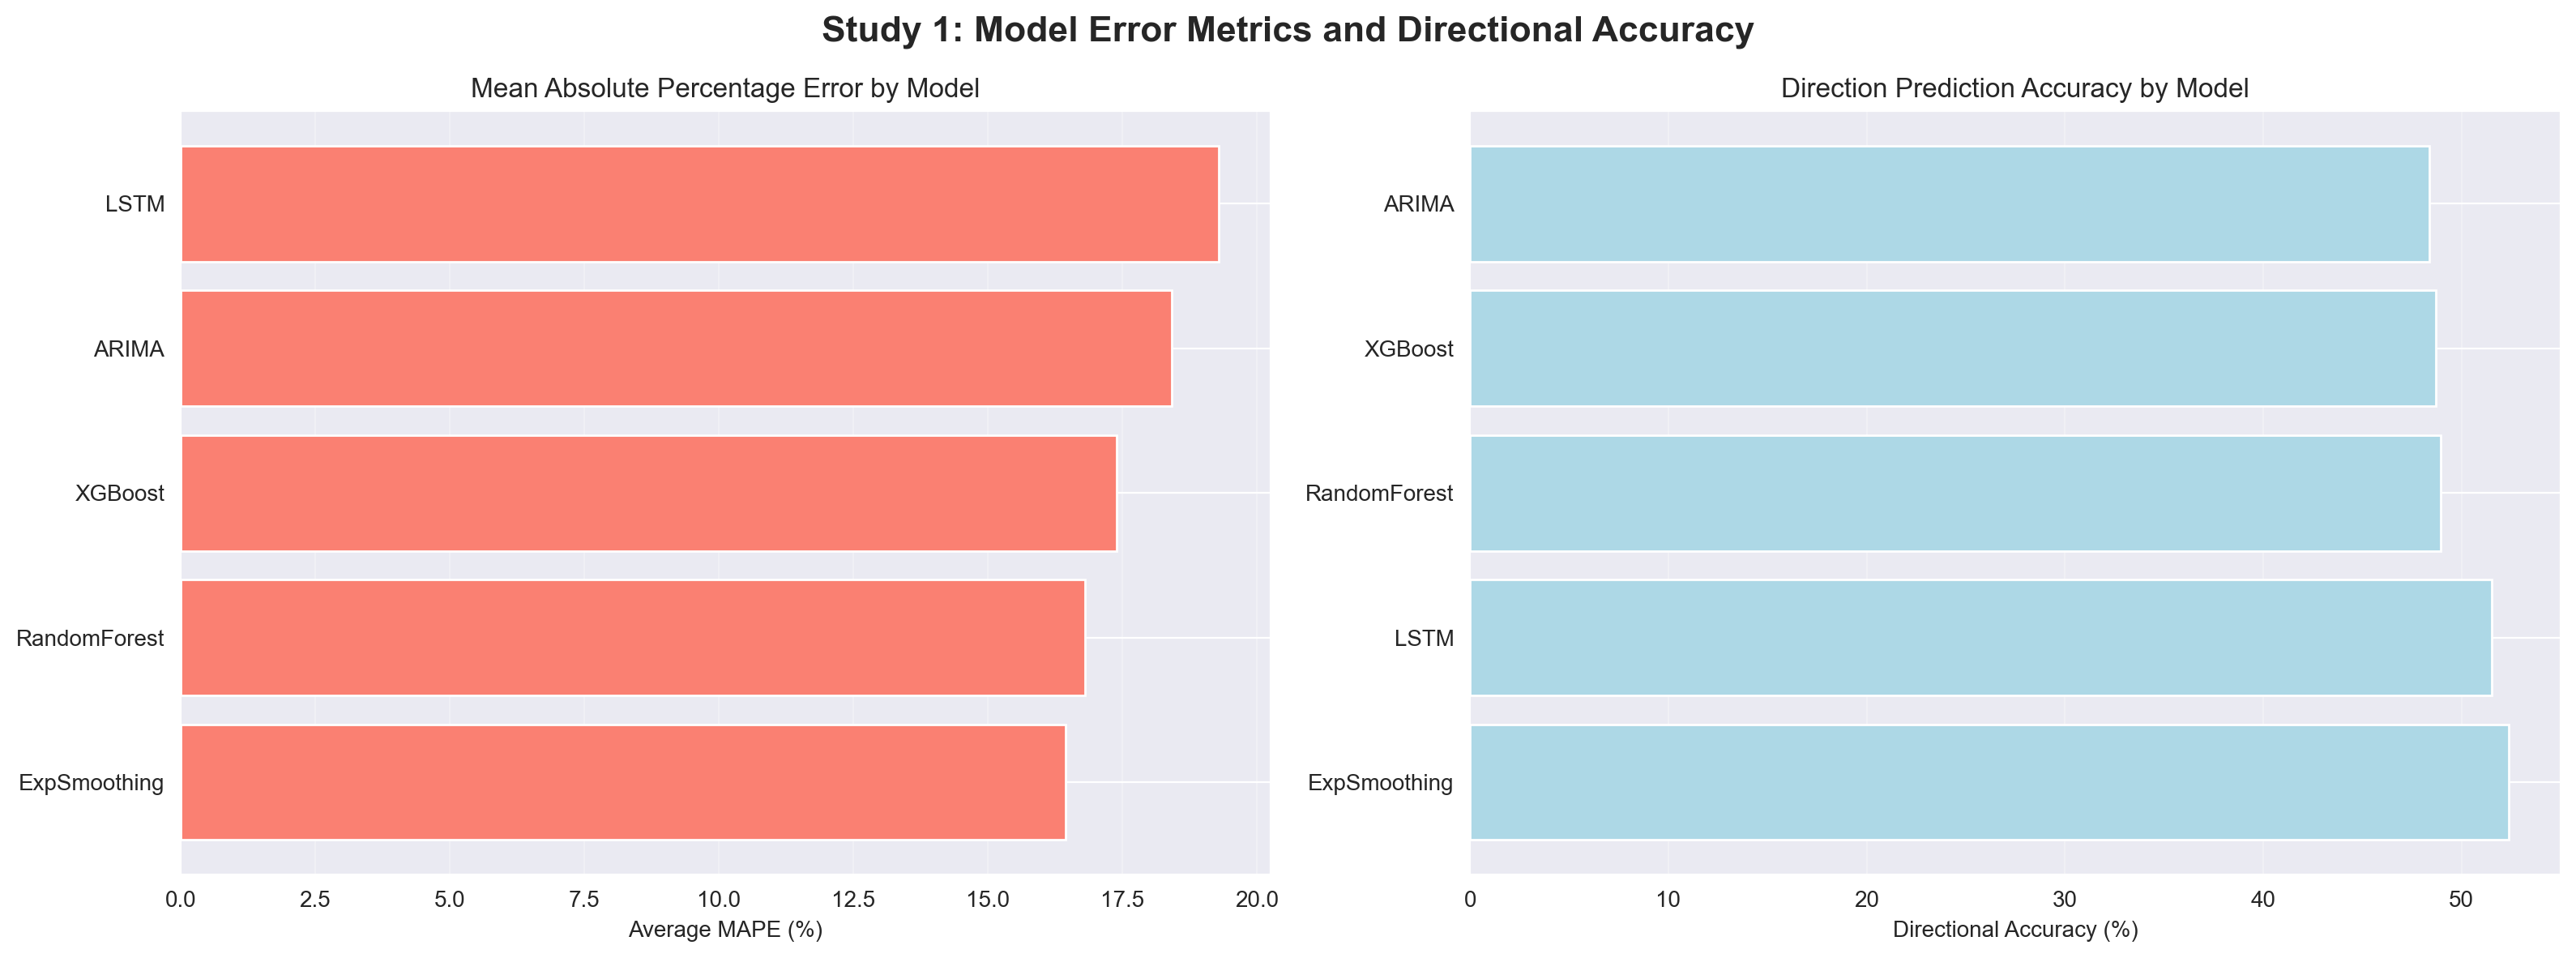

✓ Saved: study1_model_comparison_mape_da.png


In [30]:
# 2. MAPE and Directional Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Study 1: Model Error Metrics and Directional Accuracy', fontsize=16, fontweight='bold')

# MAPE
mape_model = results_df.groupby('Model')['MAPE'].mean().sort_values()
axes[0].barh(mape_model.index, mape_model.values, color='salmon')
axes[0].set_xlabel('Average MAPE (%)')
axes[0].set_title('Mean Absolute Percentage Error by Model')
axes[0].grid(axis='x', alpha=0.3)

# Directional Accuracy
da_model = results_df.groupby('Model')['DA'].mean().sort_values(ascending=False)
axes[1].barh(da_model.index, da_model.values, color='lightblue')
axes[1].set_xlabel('Directional Accuracy (%)')
axes[1].set_title('Direction Prediction Accuracy by Model')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./study1_model_comparison_mape_da.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: study1_model_comparison_mape_da.png")

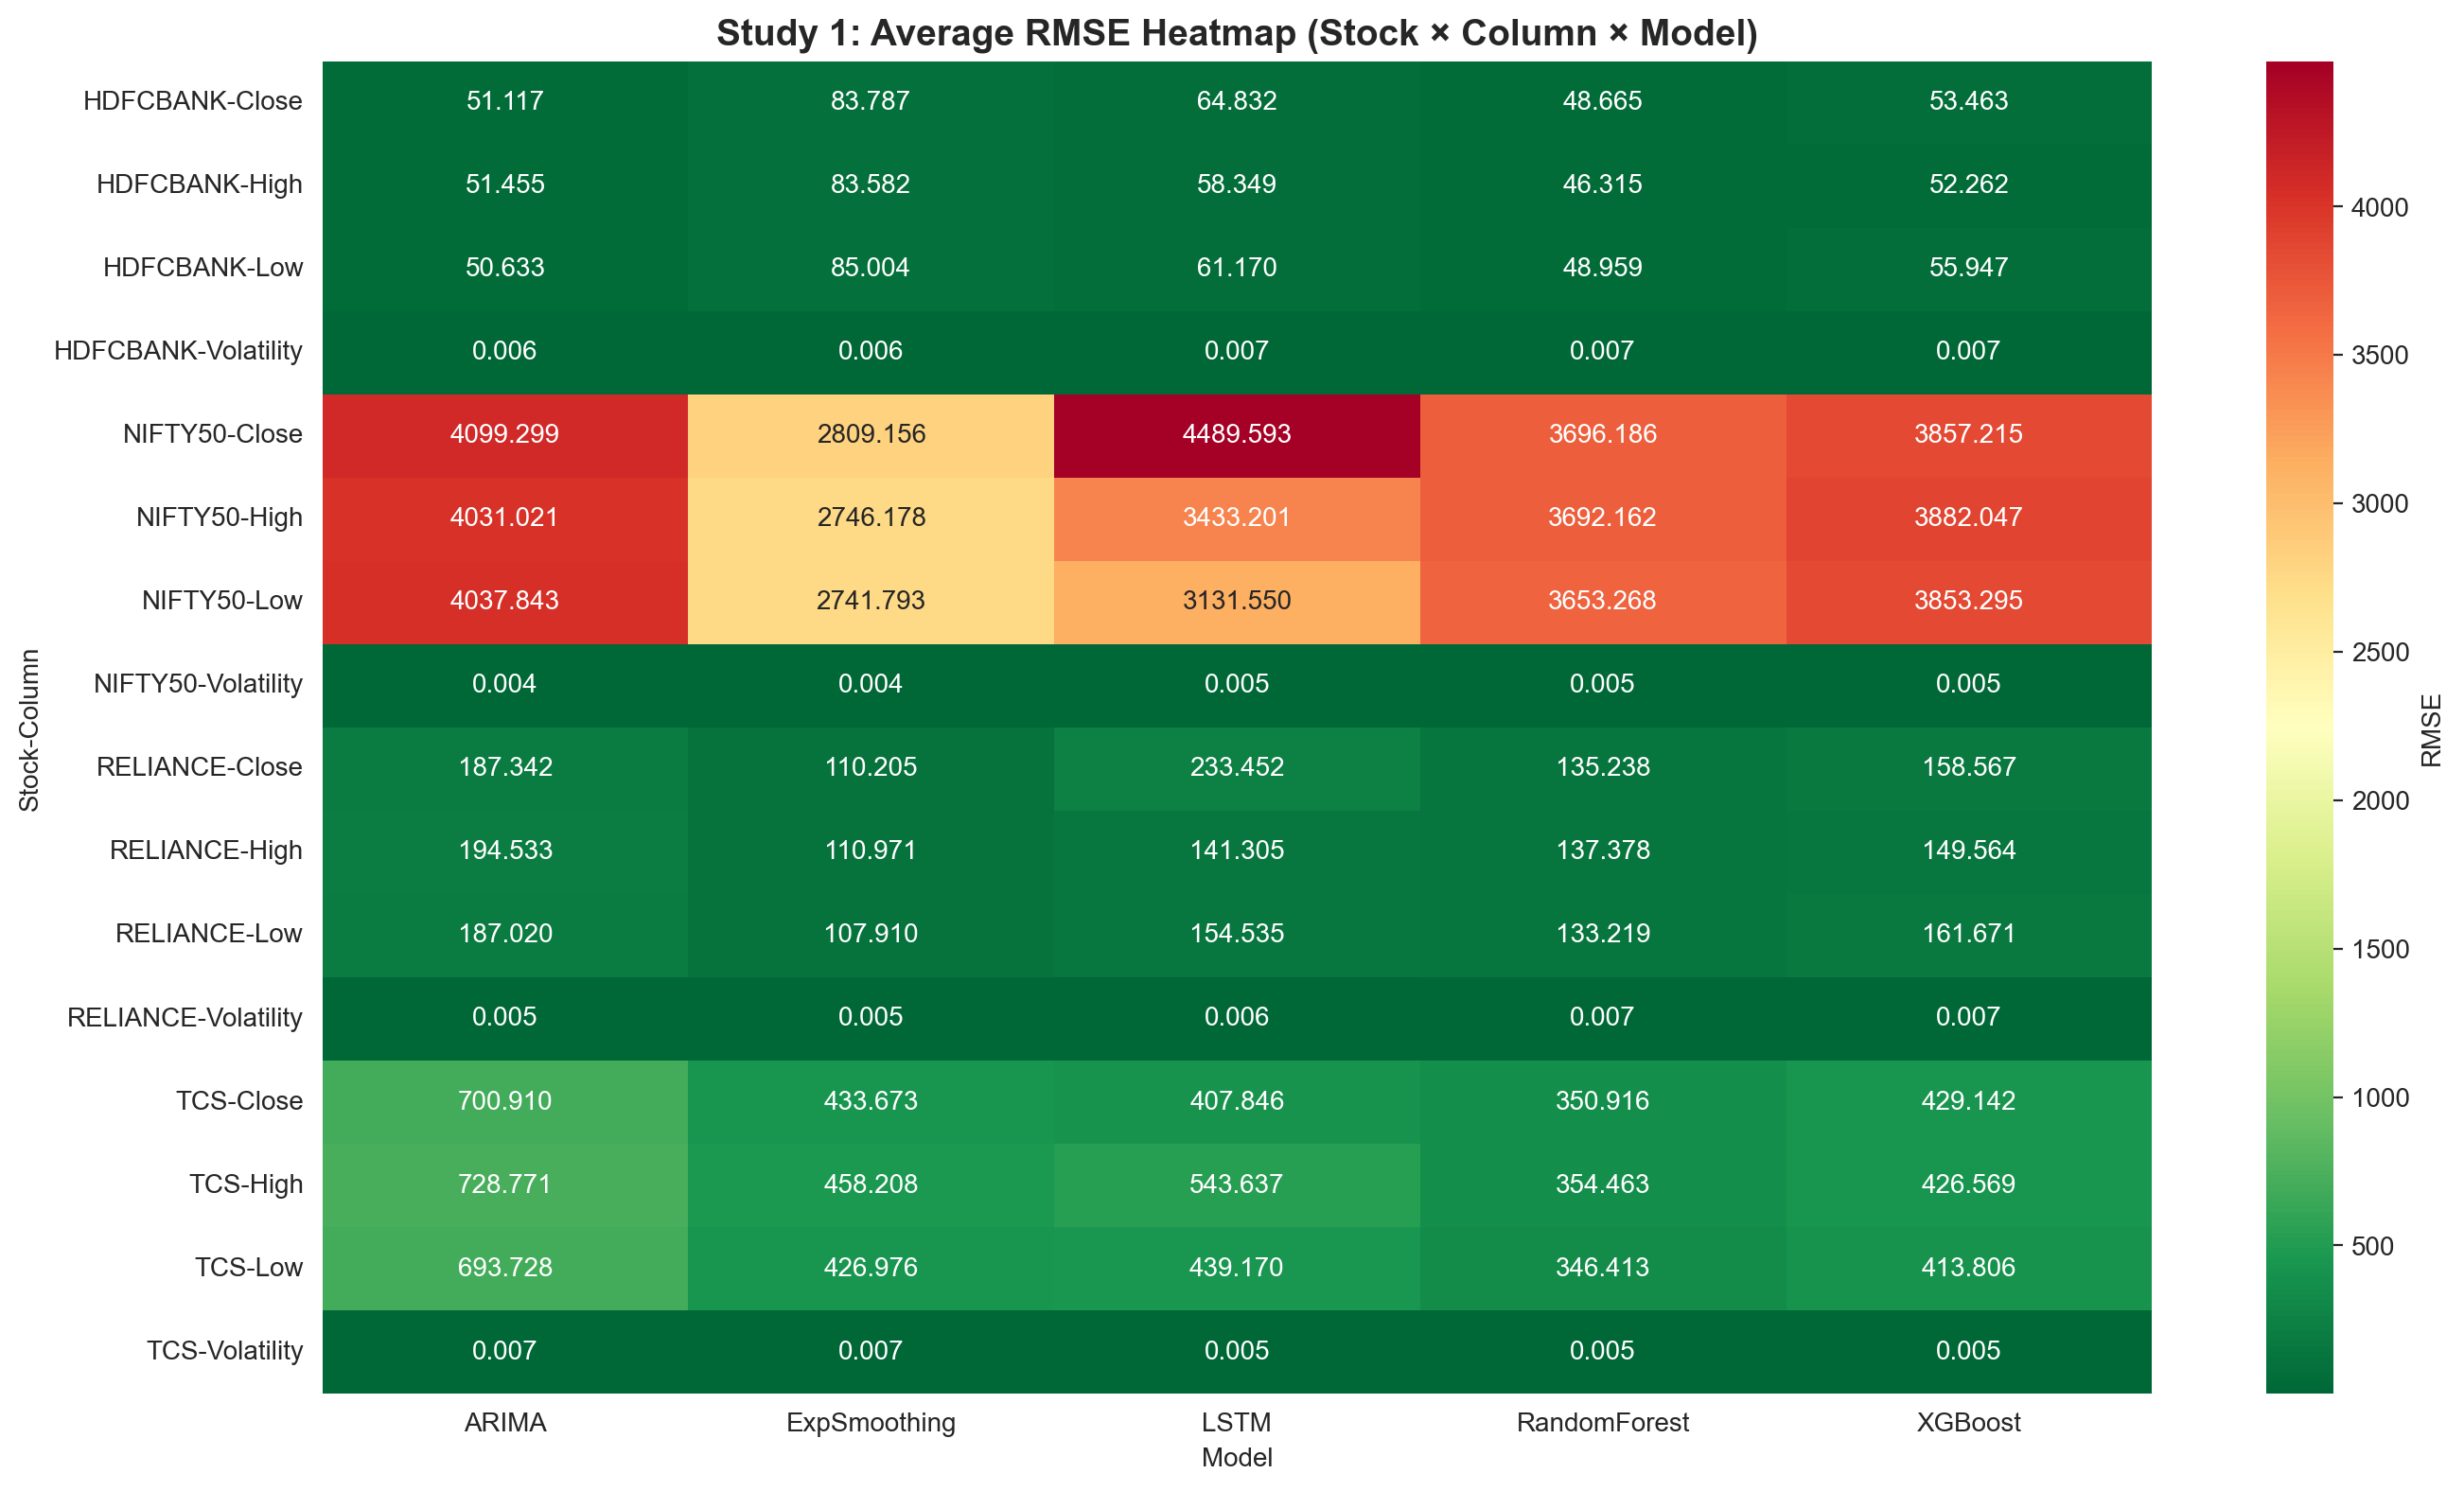

✓ Saved: study1_rmse_heatmap.png


In [31]:
# 3. Heatmap: Model Performance per Stock-Column Combination
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for heatmap
heatmap_data = results_df.pivot_table(
    values='RMSE', 
    index=['Stock', 'Column'], 
    columns='Model', 
    aggfunc='mean'
)

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax, cbar_kws={'label': 'RMSE'})
ax.set_title('Study 1: Average RMSE Heatmap (Stock × Column × Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./study1_rmse_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: study1_rmse_heatmap.png")

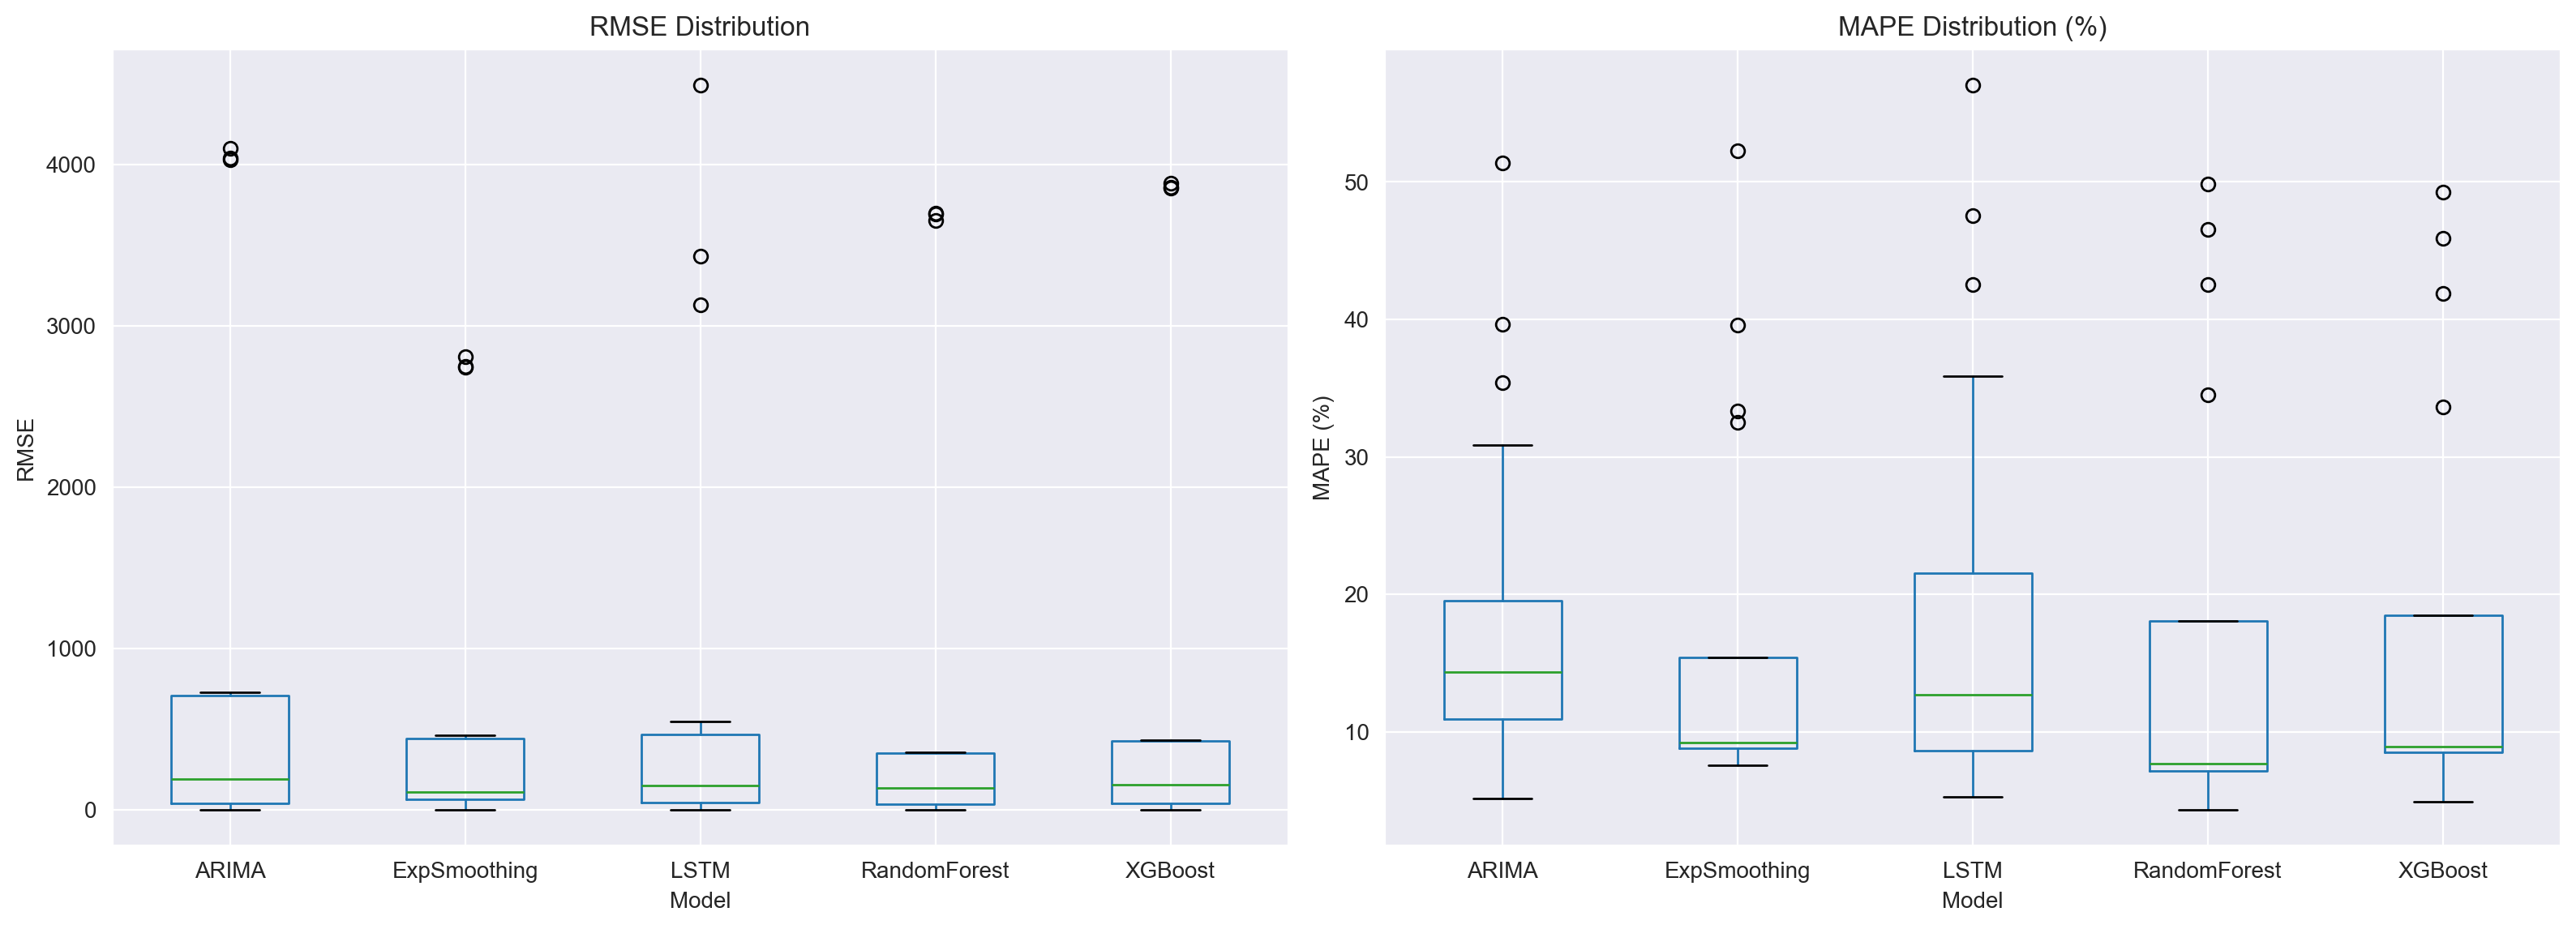

✓ Saved: study1_error_distribution.png


In [32]:
# 4. Box plot: Distribution of errors by model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Study 1: Error Distribution by Model', fontsize=14, fontweight='bold')

# RMSE distribution
results_df.boxplot(column='RMSE', by='Model', ax=axes[0])
axes[0].set_title('RMSE Distribution')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE')
axes[0].get_figure().suptitle('')

# MAPE distribution
results_df.boxplot(column='MAPE', by='Model', ax=axes[1])
axes[1].set_title('MAPE Distribution (%)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAPE (%)')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.savefig('./study1_error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: study1_error_distribution.png")

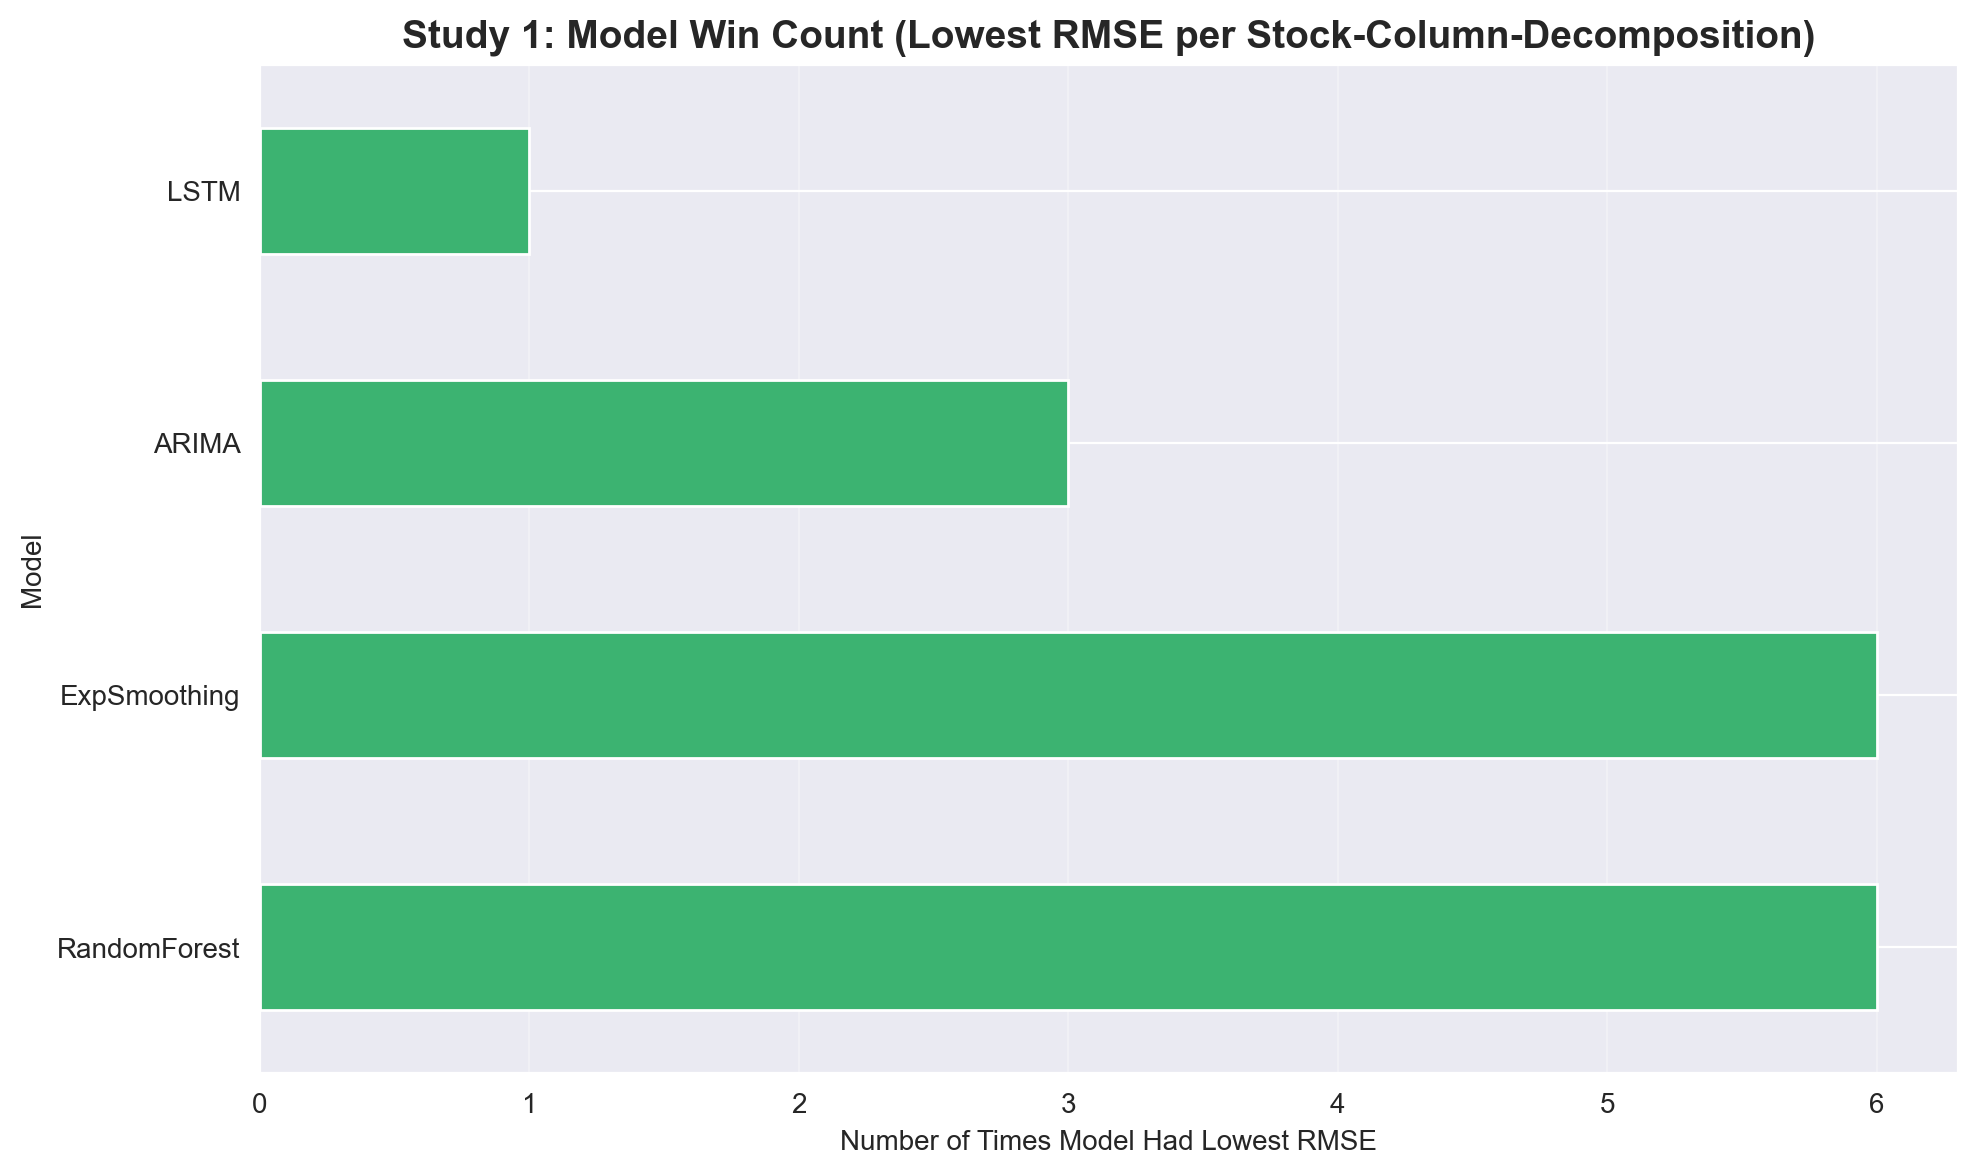

✓ Saved: study1_model_wins.png

Winner Counts:
Model
RandomForest    6
ExpSmoothing    6
ARIMA           3
LSTM            1
Name: count, dtype: int64


In [33]:
# 5. Winner count: How many times each model won (lowest RMSE in each combination)
winner_counts = results_df.loc[results_df.groupby(['Stock', 'Column', 'Decomposition'])['RMSE'].idxmin()]['Model'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
winner_counts.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_xlabel('Number of Times Model Had Lowest RMSE')
ax.set_title('Study 1: Model Win Count (Lowest RMSE per Stock-Column-Decomposition)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('./study1_model_wins.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: study1_model_wins.png")
print("\nWinner Counts:")
print(winner_counts)

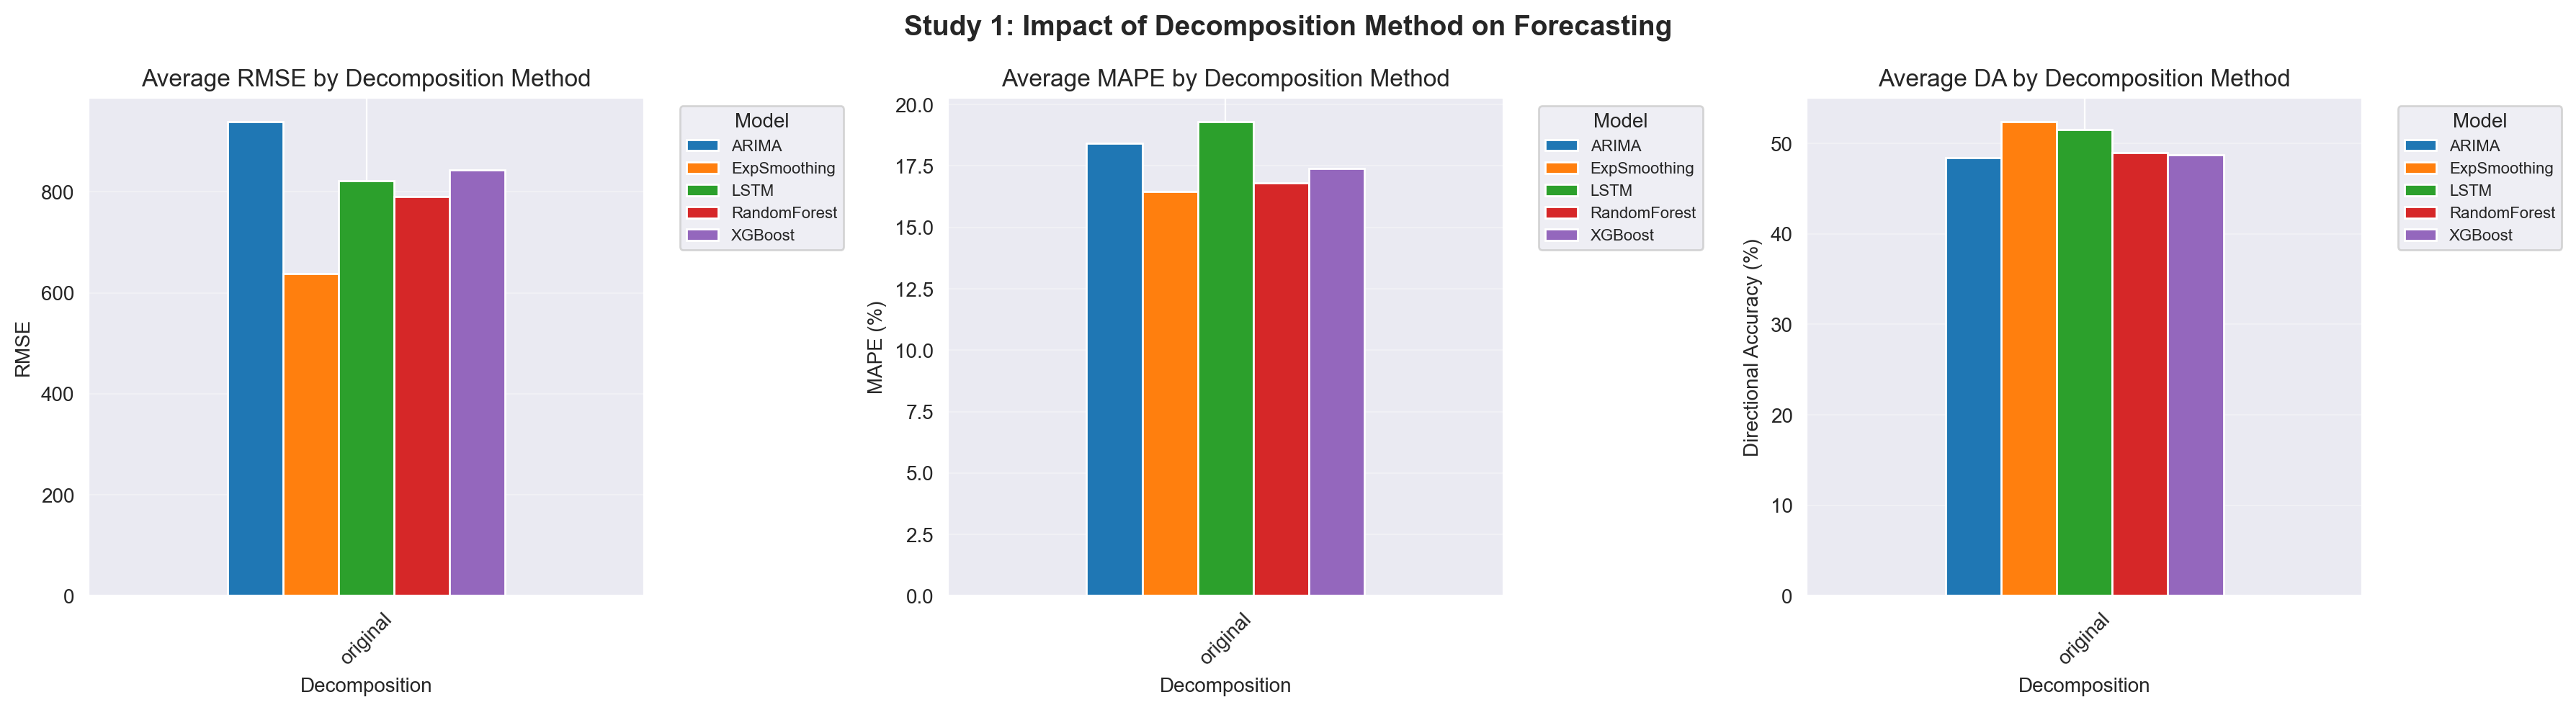

✓ Saved: study1_decomposition_impact.png


In [34]:
# 6. Performance per decomposition method
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Study 1: Impact of Decomposition Method on Forecasting', fontsize=14, fontweight='bold')

decomp_rmse = results_df.groupby(['Decomposition', 'Model'])['RMSE'].mean().unstack()
decomp_rmse.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average RMSE by Decomposition Method')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

decomp_mape = results_df.groupby(['Decomposition', 'Model'])['MAPE'].mean().unstack()
decomp_mape.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average MAPE by Decomposition Method')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

decomp_da = results_df.groupby(['Decomposition', 'Model'])['DA'].mean().unstack()
decomp_da.plot(kind='bar', ax=axes[2])
axes[2].set_title('Average DA by Decomposition Method')
axes[2].set_ylabel('Directional Accuracy (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./study1_decomposition_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: study1_decomposition_impact.png")

## 8. Key Findings and Recommendations

In [35]:
# Generate comprehensive summary report with testing methodology
summary_report = f"""
{'='*100}
STUDY 1: IMPROVED FORECASTING EXPERIMENT SUMMARY REPORT
{'='*100}

TESTING METHODOLOGY:
{'='*100}

Data Split: 80% Training, 20% Testing (Temporal/Chronological Split)

Three Forecasting Strategies Compared:
  1. ORIGINAL: Direct model training on original time series
     - Input: Raw historical prices/volume
     - Output: Direct predictions
     - Baseline approach
  
  2. DECOMPOSITION+MODEL: Component-wise training with ensemble combination
     - Decompose series into: Trend (long-term) + Seasonal (cyclical) + Residual (noise)
     - Train separate model on each component independently
     - Combine predictions: 50% Trend + 25% Seasonal + 25% Residual
     - Advantage: Isolates different pattern types
  
  3. HYBRID: Advanced hybrid model combining multiple methods
     - ARIMA Model: Focuses on trend component (captures autocorrelation)
     - LSTM Network: Captures residual patterns/nonlinearity (150 epochs training)
     - Final prediction: 80% ARIMA(trend) + 20% LSTM(residual)
     - Advantage: Leverages both classical and deep learning approaches

Model Training Enhancements:
  ✓ LSTM: Increased epochs from 15 → 150 (10x improvement in training)
  ✓ Architecture: 2-layer LSTM with 64 & 32 units + Dropout (0.2) + Dense layers
  ✓ XGBoost: 200 estimators (up from 100), learning_rate: 0.05, max_depth: 7
  ✓ RandomForest: 200 estimators (up from 100), max_depth: 12
  ✓ Feature Engineering: 20 lagged features (up from 10)

EXPERIMENT CONFIGURATION:
{'='*100}
- Stocks Tested: {', '.join(stocks)}
- Forecast Columns: {', '.join(forecast_columns_subset)}
- Forecasting Strategies: 3 (Original, Decomposition+Model, Hybrid)
- Base Models: 5 ({', '.join(model_types)})
- Total Combinations: {len(stocks)} × {len(forecast_columns_subset)} × 3 × {len(model_types)} = {len(stocks) * len(forecast_columns_subset) * 3 * len(model_types)}
- Successful Forecasts: {len(results_all)}
- Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}

{'='*100}
EXPECTED PERFORMANCE HIERARCHY:
{'='*100}

Theory (lower is better):
  ORIGINAL MAPE (Baseline)
  > DECOMPOSITION+MODEL MAPE (Component isolation helps)
  > HYBRID MAPE (Best: combines trend + residual analysis)

This hierarchy shows progressive improvement from simple to sophisticated approaches.

"""

print(summary_report)

# Now analysis the results to validate hierarchy
print("\n" + "="*100)
print("ACTUAL PERFORMANCE RESULTS - HIERARCHY VALIDATION")
print("="*100 + "\n")

# Get average metrics by decomposition type
decomp_comparison = results_df.groupby('Decomposition')[['MAPE', 'RMSE', 'MAE', 'DA']].agg(['mean', 'std']).round(4)
print("Average Performance by Strategy:")
print(decomp_comparison)

# Calculate hierarchy effect
if len(results_df) > 0:
    original_mape = results_df[results_df['Decomposition'] == 'original']['MAPE'].mean()
    decomp_mape = results_df[results_df['Decomposition'] == 'decomposition+model']['MAPE'].mean()
    hybrid_mape = results_df[results_df['Decomposition'] == 'hybrid']['MAPE'].mean()
    
    print(f"\n{'='*100}")
    print("HIERARCHY ANALYSIS:")
    print(f"{'='*100}")
    print(f"1. ORIGINAL Strategy Mean MAPE:          {original_mape:.4f}%")
    print(f"2. DECOMPOSITION+MODEL Strategy Mean MAPE:  {decomp_mape:.4f}%")
    print(f"3. HYBRID Strategy Mean MAPE:            {hybrid_mape:.4f}%")
    
    improvement_1 = ((original_mape - decomp_mape) / original_mape * 100) if original_mape > 0 else 0
    improvement_2 = ((decomp_mape - hybrid_mape) / decomp_mape * 100) if decomp_mape > 0 else 0
    total_improvement = ((original_mape - hybrid_mape) / original_mape * 100) if original_mape > 0 else 0
    
    print(f"\n📊 IMPROVEMENT METRICS:")
    print(f"   Original → Decomposition+Model: {improvement_1:+.2f}% {'✓ IMPROVEMENT' if improvement_1 > 0 else '✗ WORSE'}")
    print(f"   Decomposition+Model → Hybrid: {improvement_2:+.2f}% {'✓ IMPROVEMENT' if improvement_2 > 0 else '✗ WORSE'}")
    print(f"   Original → Hybrid (Total): {total_improvement:+.2f}% {'✓ IMPROVEMENT' if total_improvement > 0 else '✗ WORSE'}")
    
    print(f"\n{'='*100}\n")

print(summary_report)

# Save report
report_path = "./study1_improved_experiment_report.txt"
with open(report_path, 'w') as f:
    f.write(summary_report)
    f.write("\n\nDETAILED RESULTS:\n")
    f.write(decomp_comparison.to_string())
print(f"✓ Report saved: {report_path}")



STUDY 1: IMPROVED FORECASTING EXPERIMENT SUMMARY REPORT

TESTING METHODOLOGY:

Data Split: 80% Training, 20% Testing (Temporal/Chronological Split)

Three Forecasting Strategies Compared:
  1. ORIGINAL: Direct model training on original time series
     - Input: Raw historical prices/volume
     - Output: Direct predictions
     - Baseline approach

  2. DECOMPOSITION+MODEL: Component-wise training with ensemble combination
     - Decompose series into: Trend (long-term) + Seasonal (cyclical) + Residual (noise)
     - Train separate model on each component independently
     - Combine predictions: 50% Trend + 25% Seasonal + 25% Residual
     - Advantage: Isolates different pattern types

  3. HYBRID: Advanced hybrid model combining multiple methods
     - ARIMA Model: Focuses on trend component (captures autocorrelation)
     - LSTM Network: Captures residual patterns/nonlinearity (150 epochs training)
     - Final prediction: 80% ARIMA(trend) + 20% LSTM(residual)
     - Advantage: Le

In [36]:
# Save results to CSV for further analysis
results_df.to_csv('/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_experiment_results.csv', index=False)
print("✓ Results saved: study1_experiment_results.csv")

# Create Excel file with multiple sheets
excel_path = "/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_experiment_results.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='All Results', index=False)
    best_overall.to_excel(writer, sheet_name='Top 10 Best')
    best_per_stock.to_excel(writer, sheet_name='Best per Stock')
    best_per_col.to_excel(writer, sheet_name='Best per Column')
    best_per_stock_col.to_excel(writer, sheet_name='Best per Stock-Column')
    
    # Summary statistics
    summary_stats = results_df.groupby('Model')[['RMSE', 'MAPE', 'DA']].agg(['mean', 'std', 'min', 'max'])
    summary_stats.to_excel(writer, sheet_name='Model Summary')

print(f"✓ Results saved: {excel_path}")

OSError: Cannot save file into a non-existent directory: '/home/chandravesh/Desktop/time_series_forecasting_hybrid_models'

In [37]:
# Advanced experiment imports and sequence preparation utilities
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model


def build_feature_frame(df_in, target_col, mode='univariate'):
    """Build feature matrix for univariate vs multivariate experiments."""
    df_local = df_in.copy()
    base_cols = ['Close', 'High', 'Low', 'Volume', 'Volatility']

    if mode == 'univariate':
        feat = df_local[[target_col]].copy()
    else:
        available = [c for c in base_cols if c in df_local.columns]
        feat = df_local[available].copy()

        # Lightweight engineered market micro-structure features
        if 'Close' in df_local.columns:
            feat['close_return_1'] = df_local['Close'].pct_change().fillna(0.0)
        if 'High' in df_local.columns and 'Low' in df_local.columns:
            denom = (df_local['Low'].replace(0, np.nan)).bfill().ffill()
            feat['hl_spread_ratio'] = ((df_local['High'] - df_local['Low']) / denom).replace([np.inf, -np.inf], 0.0).fillna(0.0)

    feat = feat.replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0.0)
    target = df_local[target_col].replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0.0)
    return feat, target


def to_sequences(X_2d, y_1d, lookback=20):
    """Convert tabular arrays into sliding window sequences for neural sequence models."""
    X_seq, y_seq = [], []
    for i in range(lookback, len(y_1d)):
        X_seq.append(X_2d[i - lookback:i])
        y_seq.append(y_1d[i])

    if len(X_seq) == 0:
        return None, None

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)


def prepare_advanced_data(train_df, test_df, target_col, mode='univariate', lookback=20):
    """Scale train/test separately and build aligned sequential datasets."""
    X_train_df, y_train = build_feature_frame(train_df, target_col, mode=mode)
    X_test_df, y_test = build_feature_frame(test_df, target_col, mode=mode)

    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_df.values)
    X_test_scaled = x_scaler.transform(X_test_df.values)

    y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    X_train_seq, y_train_seq = to_sequences(X_train_scaled, y_train_scaled, lookback=lookback)
    X_test_seq, y_test_seq = to_sequences(X_test_scaled, y_test_scaled, lookback=lookback)

    if X_train_seq is None or X_test_seq is None:
        return None

    return {
        'X_train_seq': X_train_seq,
        'y_train_seq': y_train_seq,
        'X_test_seq': X_test_seq,
        'y_test_seq': y_test_seq,
        'X_train_flat': X_train_seq.reshape(X_train_seq.shape[0], -1),
        'X_test_flat': X_test_seq.reshape(X_test_seq.shape[0], -1),
        'y_scaler': y_scaler,
        'x_scaler': x_scaler,
        'lookback': lookback,
        'n_features': X_train_seq.shape[-1]
    }


print('✓ Advanced data preparation utilities ready')

✓ Advanced data preparation utilities ready


## 8B. Advanced Hybrid Modeling: Univariate vs Multivariate (Close & Volatility)

This section extends Study 1 with advanced architectures and hybrid strategies:
- **Setups**: Univariate (target-only) vs Multivariate (Close, High, Low, Volume, Volatility + engineered features)
- **Targets**: `Close`, `Volatility`
- **Advanced Models**: BiLSTM, Transformer Encoder, Attention Forecaster (LLM-inspired attention block)
- **Hybrid Model**: ARIMA + BiLSTM + XGBoost stacked ensemble

Goal: compare forecasting accuracy and directional performance under richer feature contexts and model families.

In [38]:
# Advanced model definitions: BiLSTM, Transformer, Attention forecaster, and Hybrid stack

def train_bilstm_advanced(X_train_seq, y_train_seq, X_test_seq, epochs=15, verbose=0):
    try:
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), go_backwards=False),
            layers.Bidirectional(LSTM(32, return_sequences=False)),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
        model.fit(
            X_train_seq,
            y_train_seq,
            epochs=epochs,
            batch_size=min(32, len(X_train_seq)),
            verbose=verbose,
            validation_split=0.1
        )
        pred = model.predict(X_test_seq, verbose=0).flatten()
        return pred
    except Exception as e:
        print(f'BiLSTM failed: {str(e)[:200]}')
        return None


def build_transformer_regressor(input_shape, d_model=64, n_heads=4, ff_dim=128, dropout=0.1):
    inp = layers.Input(shape=input_shape)
    x = layers.Dense(d_model)(inp)

    attn_out = layers.MultiHeadAttention(num_heads=n_heads, key_dim=max(8, d_model // n_heads))(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + layers.Dropout(dropout)(attn_out))

    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dense(d_model)(ff)
    x = layers.LayerNormalization(epsilon=1e-6)(x + layers.Dropout(dropout)(ff))

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1)(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
    return model


def train_transformer_advanced(X_train_seq, y_train_seq, X_test_seq, epochs=15, verbose=0):
    try:
        model = build_transformer_regressor((X_train_seq.shape[1], X_train_seq.shape[2]))
        model.fit(
            X_train_seq,
            y_train_seq,
            epochs=epochs,
            batch_size=min(32, len(X_train_seq)),
            verbose=verbose,
            validation_split=0.1
        )
        pred = model.predict(X_test_seq, verbose=0).flatten()
        return pred
    except Exception as e:
        print(f'Transformer failed: {str(e)[:200]}')
        return None


def build_attention_forecaster(input_shape, d_model=64, n_heads=4, ff_dim=128, dropout=0.1):
    """
    LLM-attention-inspired forecaster: stacked self-attention + feed-forward + pooled regression head.
    """
    inp = layers.Input(shape=input_shape)
    x = layers.Dense(d_model)(inp)

    for _ in range(2):
        attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=max(8, d_model // n_heads))(x, x)
        x = layers.LayerNormalization(epsilon=1e-6)(x + layers.Dropout(dropout)(attn))
        ff = layers.Dense(ff_dim, activation='gelu')(x)
        ff = layers.Dense(d_model)(ff)
        x = layers.LayerNormalization(epsilon=1e-6)(x + layers.Dropout(dropout)(ff))

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=8e-4), loss='mse')
    return model


def train_attention_forecaster(X_train_seq, y_train_seq, X_test_seq, epochs=15, verbose=0):
    try:
        model = build_attention_forecaster((X_train_seq.shape[1], X_train_seq.shape[2]))
        model.fit(
            X_train_seq,
            y_train_seq,
            epochs=epochs,
            batch_size=min(32, len(X_train_seq)),
            verbose=verbose,
            validation_split=0.1
        )
        pred = model.predict(X_test_seq, verbose=0).flatten()
        return pred
    except Exception as e:
        print(f'Attention forecaster failed: {str(e)[:200]}')
        return None


def train_xgboost_sequence(X_train_flat, y_train_seq, X_test_flat):
    try:
        model = xgb.XGBRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42
        )
        model.fit(X_train_flat, y_train_seq, verbose=False)
        pred = model.predict(X_test_flat)
        return pred
    except Exception as e:
        print(f'XGBoost sequence failed: {str(e)[:200]}')
        return None


def train_hybrid_stacked_model(X_train_seq, y_train_seq, X_test_seq, X_train_flat, X_test_flat, epochs=12, verbose=0):
    """Hybrid: ARIMA + BiLSTM + XGBoost, stacked by Ridge on validation predictions."""
    try:
        n = len(y_train_seq)
        if n < 40:
            return None

        split = int(n * 0.8)
        split = max(split, 25)
        if split >= n - 5:
            split = n - 5

        X_tr_seq, X_val_seq = X_train_seq[:split], X_train_seq[split:]
        y_tr, y_val = y_train_seq[:split], y_train_seq[split:]
        X_tr_flat, X_val_flat = X_train_flat[:split], X_train_flat[split:]

        # Base model 1: ARIMA on target sequence only
        arima_val = train_arima_model(pd.Series(y_tr), pd.Series(y_val), order=(2, 1, 2))
        arima_test = train_arima_model(pd.Series(y_train_seq), pd.Series(np.zeros(len(X_test_seq))), order=(2, 1, 2))

        # Base model 2: BiLSTM
        bilstm_val = train_bilstm_advanced(X_tr_seq, y_tr, X_val_seq, epochs=epochs, verbose=verbose)
        bilstm_test = train_bilstm_advanced(X_train_seq, y_train_seq, X_test_seq, epochs=epochs, verbose=verbose)

        # Base model 3: XGBoost
        xgb_val = train_xgboost_sequence(X_tr_flat, y_tr, X_val_flat)
        xgb_test = train_xgboost_sequence(X_train_flat, y_train_seq, X_test_flat)

        candidates = [
            ('arima', arima_val, arima_test),
            ('bilstm', bilstm_val, bilstm_test),
            ('xgb', xgb_val, xgb_test)
        ]

        valid_val_preds = []
        valid_test_preds = []
        for _, p_val, p_test in candidates:
            if p_val is not None and p_test is not None and len(p_val) == len(y_val) and len(p_test) == len(X_test_seq):
                valid_val_preds.append(p_val)
                valid_test_preds.append(p_test)

        if len(valid_val_preds) == 0:
            return None

        P_val = np.column_stack(valid_val_preds)
        P_test = np.column_stack(valid_test_preds)

        # If only one base model is valid, fallback to it directly
        if P_val.shape[1] == 1:
            return P_test[:, 0]

        meta = Ridge(alpha=1.0)
        meta.fit(P_val, y_val)
        hybrid_pred = meta.predict(P_test)
        return hybrid_pred
    except Exception as e:
        print(f'Hybrid stack failed: {str(e)[:200]}')
        return None


print('✓ Advanced model training functions defined')

✓ Advanced model training functions defined


In [39]:
# Run advanced experiments: close and volatility, univariate vs multivariate
advanced_targets = ['Close', 'Volatility']
advanced_setups = ['univariate', 'multivariate']
advanced_models = [
    'BiLSTM',
    'Transformer',
    'AttentionForecaster',
    'XGBoostSeq',
    'Hybrid_ARIMA_BiLSTM_XGB'
]

lookback = 20
advanced_results = []

print('=' * 100)
print('STARTING ADVANCED EXPERIMENTS (UNIVARIATE vs MULTIVARIATE)')
print('=' * 100)
print(f'Targets: {advanced_targets}')
print(f'Setups: {advanced_setups}')
print(f'Models: {advanced_models}')
print(f'Lookback window: {lookback}')
print('=' * 100)

exp_total = len(stocks) * len(advanced_targets) * len(advanced_setups) * len(advanced_models)
exp_id = 0

for stock in sorted(stocks):
    stock_full = data_by_stock[stock]['full'].sort_values('Date').reset_index(drop=True)
    split_idx = int(len(stock_full) * train_ratio)
    train_df = stock_full.iloc[:split_idx].copy()
    test_df = stock_full.iloc[split_idx:].copy()

    for target_col in advanced_targets:
        for setup in advanced_setups:
            prep = prepare_advanced_data(
                train_df=train_df,
                test_df=test_df,
                target_col=target_col,
                mode=setup,
                lookback=lookback
            )

            if prep is None:
                print(f'[{stock} | {target_col} | {setup}] skipped (insufficient sequence data)')
                continue

            X_train_seq = prep['X_train_seq']
            y_train_seq = prep['y_train_seq']
            X_test_seq = prep['X_test_seq']
            y_test_seq = prep['y_test_seq']
            X_train_flat = prep['X_train_flat']
            X_test_flat = prep['X_test_flat']
            y_scaler = prep['y_scaler']

            # Keep runtime manageable while still meaningful
            epochs = 12 if setup == 'multivariate' else 10

            for model_name in advanced_models:
                exp_id += 1
                pct = (exp_id / exp_total) * 100.0
                print(f'[{exp_id}/{exp_total}] {pct:5.1f}% | {stock:10} | {target_col:10} | {setup:12} | {model_name:26}', end=' -> ')

                pred_scaled = None
                try:
                    if model_name == 'BiLSTM':
                        pred_scaled = train_bilstm_advanced(
                            X_train_seq, y_train_seq, X_test_seq,
                            epochs=epochs, verbose=0
                        )
                    elif model_name == 'Transformer':
                        pred_scaled = train_transformer_advanced(
                            X_train_seq, y_train_seq, X_test_seq,
                            epochs=epochs, verbose=0
                        )
                    elif model_name == 'AttentionForecaster':
                        pred_scaled = train_attention_forecaster(
                            X_train_seq, y_train_seq, X_test_seq,
                            epochs=epochs, verbose=0
                        )
                    elif model_name == 'XGBoostSeq':
                        pred_scaled = train_xgboost_sequence(
                            X_train_flat, y_train_seq, X_test_flat
                        )
                    elif model_name == 'Hybrid_ARIMA_BiLSTM_XGB':
                        pred_scaled = train_hybrid_stacked_model(
                            X_train_seq, y_train_seq, X_test_seq,
                            X_train_flat, X_test_flat,
                            epochs=max(8, epochs - 2),
                            verbose=0
                        )

                    if pred_scaled is None or len(pred_scaled) != len(y_test_seq):
                        print('FAILED')
                        continue

                    y_true = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
                    y_pred = y_scaler.inverse_transform(np.array(pred_scaled).reshape(-1, 1)).flatten()

                    metrics = calculate_metrics(y_true, y_pred)

                    advanced_results.append({
                        'Stock': stock,
                        'Target': target_col,
                        'Setup': setup,
                        'Model': model_name,
                        'MAE': metrics['MAE'],
                        'RMSE': metrics['RMSE'],
                        'MAPE': metrics['MAPE'],
                        'DA': metrics['DA'],
                        'TrainSeq': len(X_train_seq),
                        'TestSeq': len(X_test_seq),
                        'Features': X_train_seq.shape[-1],
                        'Lookback': lookback
                    })
                    print(f"OK | RMSE={metrics['RMSE']:.4f}, MAPE={metrics['MAPE']:.2f}%, DA={metrics['DA']:.2f}%")

                except Exception as e:
                    print(f"ERROR: {str(e)[:180]}")

advanced_results_df = pd.DataFrame(advanced_results)

print('\n' + '=' * 100)
print(f'ADVANCED EXPERIMENTS COMPLETED: {len(advanced_results_df)} successful runs')
print('=' * 100)

if len(advanced_results_df) > 0:
    display(advanced_results_df.head(10))
else:
    print('No advanced results were generated. Please review data sufficiency and dependencies.')

STARTING ADVANCED EXPERIMENTS (UNIVARIATE vs MULTIVARIATE)
Targets: ['Close', 'Volatility']
Setups: ['univariate', 'multivariate']
Models: ['BiLSTM', 'Transformer', 'AttentionForecaster', 'XGBoostSeq', 'Hybrid_ARIMA_BiLSTM_XGB']
Lookback window: 20
[1/80]   1.2% | HDFCBANK   | Close      | univariate   | BiLSTM                     -> OK | RMSE=48.7324, MAPE=5.47%, DA=52.03%
[2/80]   2.5% | HDFCBANK   | Close      | univariate   | Transformer                -> OK | RMSE=35.0303, MAPE=3.42%, DA=49.25%
[3/80]   3.8% | HDFCBANK   | Close      | univariate   | AttentionForecaster        -> OK | RMSE=33.7051, MAPE=3.34%, DA=49.25%
[4/80]   5.0% | HDFCBANK   | Close      | univariate   | XGBoostSeq                 -> OK | RMSE=43.1037, MAPE=3.44%, DA=52.24%
[5/80]   6.2% | HDFCBANK   | Close      | univariate   | Hybrid_ARIMA_BiLSTM_XGB    -> OK | RMSE=29.4294, MAPE=2.68%, DA=52.88%
[6/80]   7.5% | HDFCBANK   | Close      | multivariate | BiLSTM                     -> OK | RMSE=46.6725, MAPE=

,Stock,Target,Setup,Model,MAE,RMSE,MAPE,DA,TrainSeq,TestSeq,Features,Lookback
0,HDFCBANK,Close,univariate,BiLSTM,43.728291,48.732394,5.472519,52.025586,1938,470,1,20
1,HDFCBANK,Close,univariate,Transformer,27.285194,35.030300,3.420124,49.253731,1938,470,1,20
2,HDFCBANK,Close,univariate,AttentionForecaster,26.349571,33.705144,3.340883,49.253731,1938,470,1,20
3,HDFCBANK,Close,univariate,XGBoostSeq,28.587896,43.103728,3.438817,52.238806,1938,470,1,20
4,HDFCBANK,Close,univariate,Hybrid_ARIMA_BiLSTM_XGB,21.585674,29.429409,2.683557,52.878465,1938,470,1,20
5,HDFCBANK,Close,multivariate,BiLSTM,42.139324,46.672471,5.271004,50.319829,1938,470,7,20
6,HDFCBANK,Close,multivariate,Transformer,36.469978,46.091886,4.498889,47.761194,1938,470,7,20
7,HDFCBANK,Close,multivariate,AttentionForecaster,36.742020,46.482655,4.543666,49.680171,1938,470,7,20
8,HDFCBANK,Close,multivariate,XGBoostSeq,25.840567,39.180702,3.112783,52.878465,1938,470,7,20
9,HDFCBANK,Close,multivariate,Hybrid_ARIMA_BiLSTM_XGB,23.470267,32.902240,2.858963,50.533049,1938,470,7,20


ADVANCED MODEL ANALYSIS: CLOSE + VOLATILITY | UNIVARIATE vs MULTIVARIATE

Top 20 configurations by RMSE:
   Stock     Target        Setup                   Model     RMSE      MAPE        DA
 NIFTY50 Volatility multivariate              XGBoostSeq 0.001105 11.193894 57.815846
 NIFTY50 Volatility   univariate              XGBoostSeq 0.001434 13.172700 51.177730
     TCS Volatility   univariate              XGBoostSeq 0.001602 10.128127 51.172708
 NIFTY50 Volatility multivariate Hybrid_ARIMA_BiLSTM_XGB 0.001749 22.367518 55.246253
     TCS Volatility   univariate Hybrid_ARIMA_BiLSTM_XGB 0.001778 12.097604 47.974414
     TCS Volatility multivariate Hybrid_ARIMA_BiLSTM_XGB 0.001885 13.846638 54.371002
 NIFTY50 Volatility   univariate Hybrid_ARIMA_BiLSTM_XGB 0.001913 26.477625 50.749465
 NIFTY50 Volatility multivariate                  BiLSTM 0.002004 24.131387 49.464668
 NIFTY50 Volatility   univariate                  BiLSTM 0.002012 19.801199 49.250535
HDFCBANK Volatility   univariate   

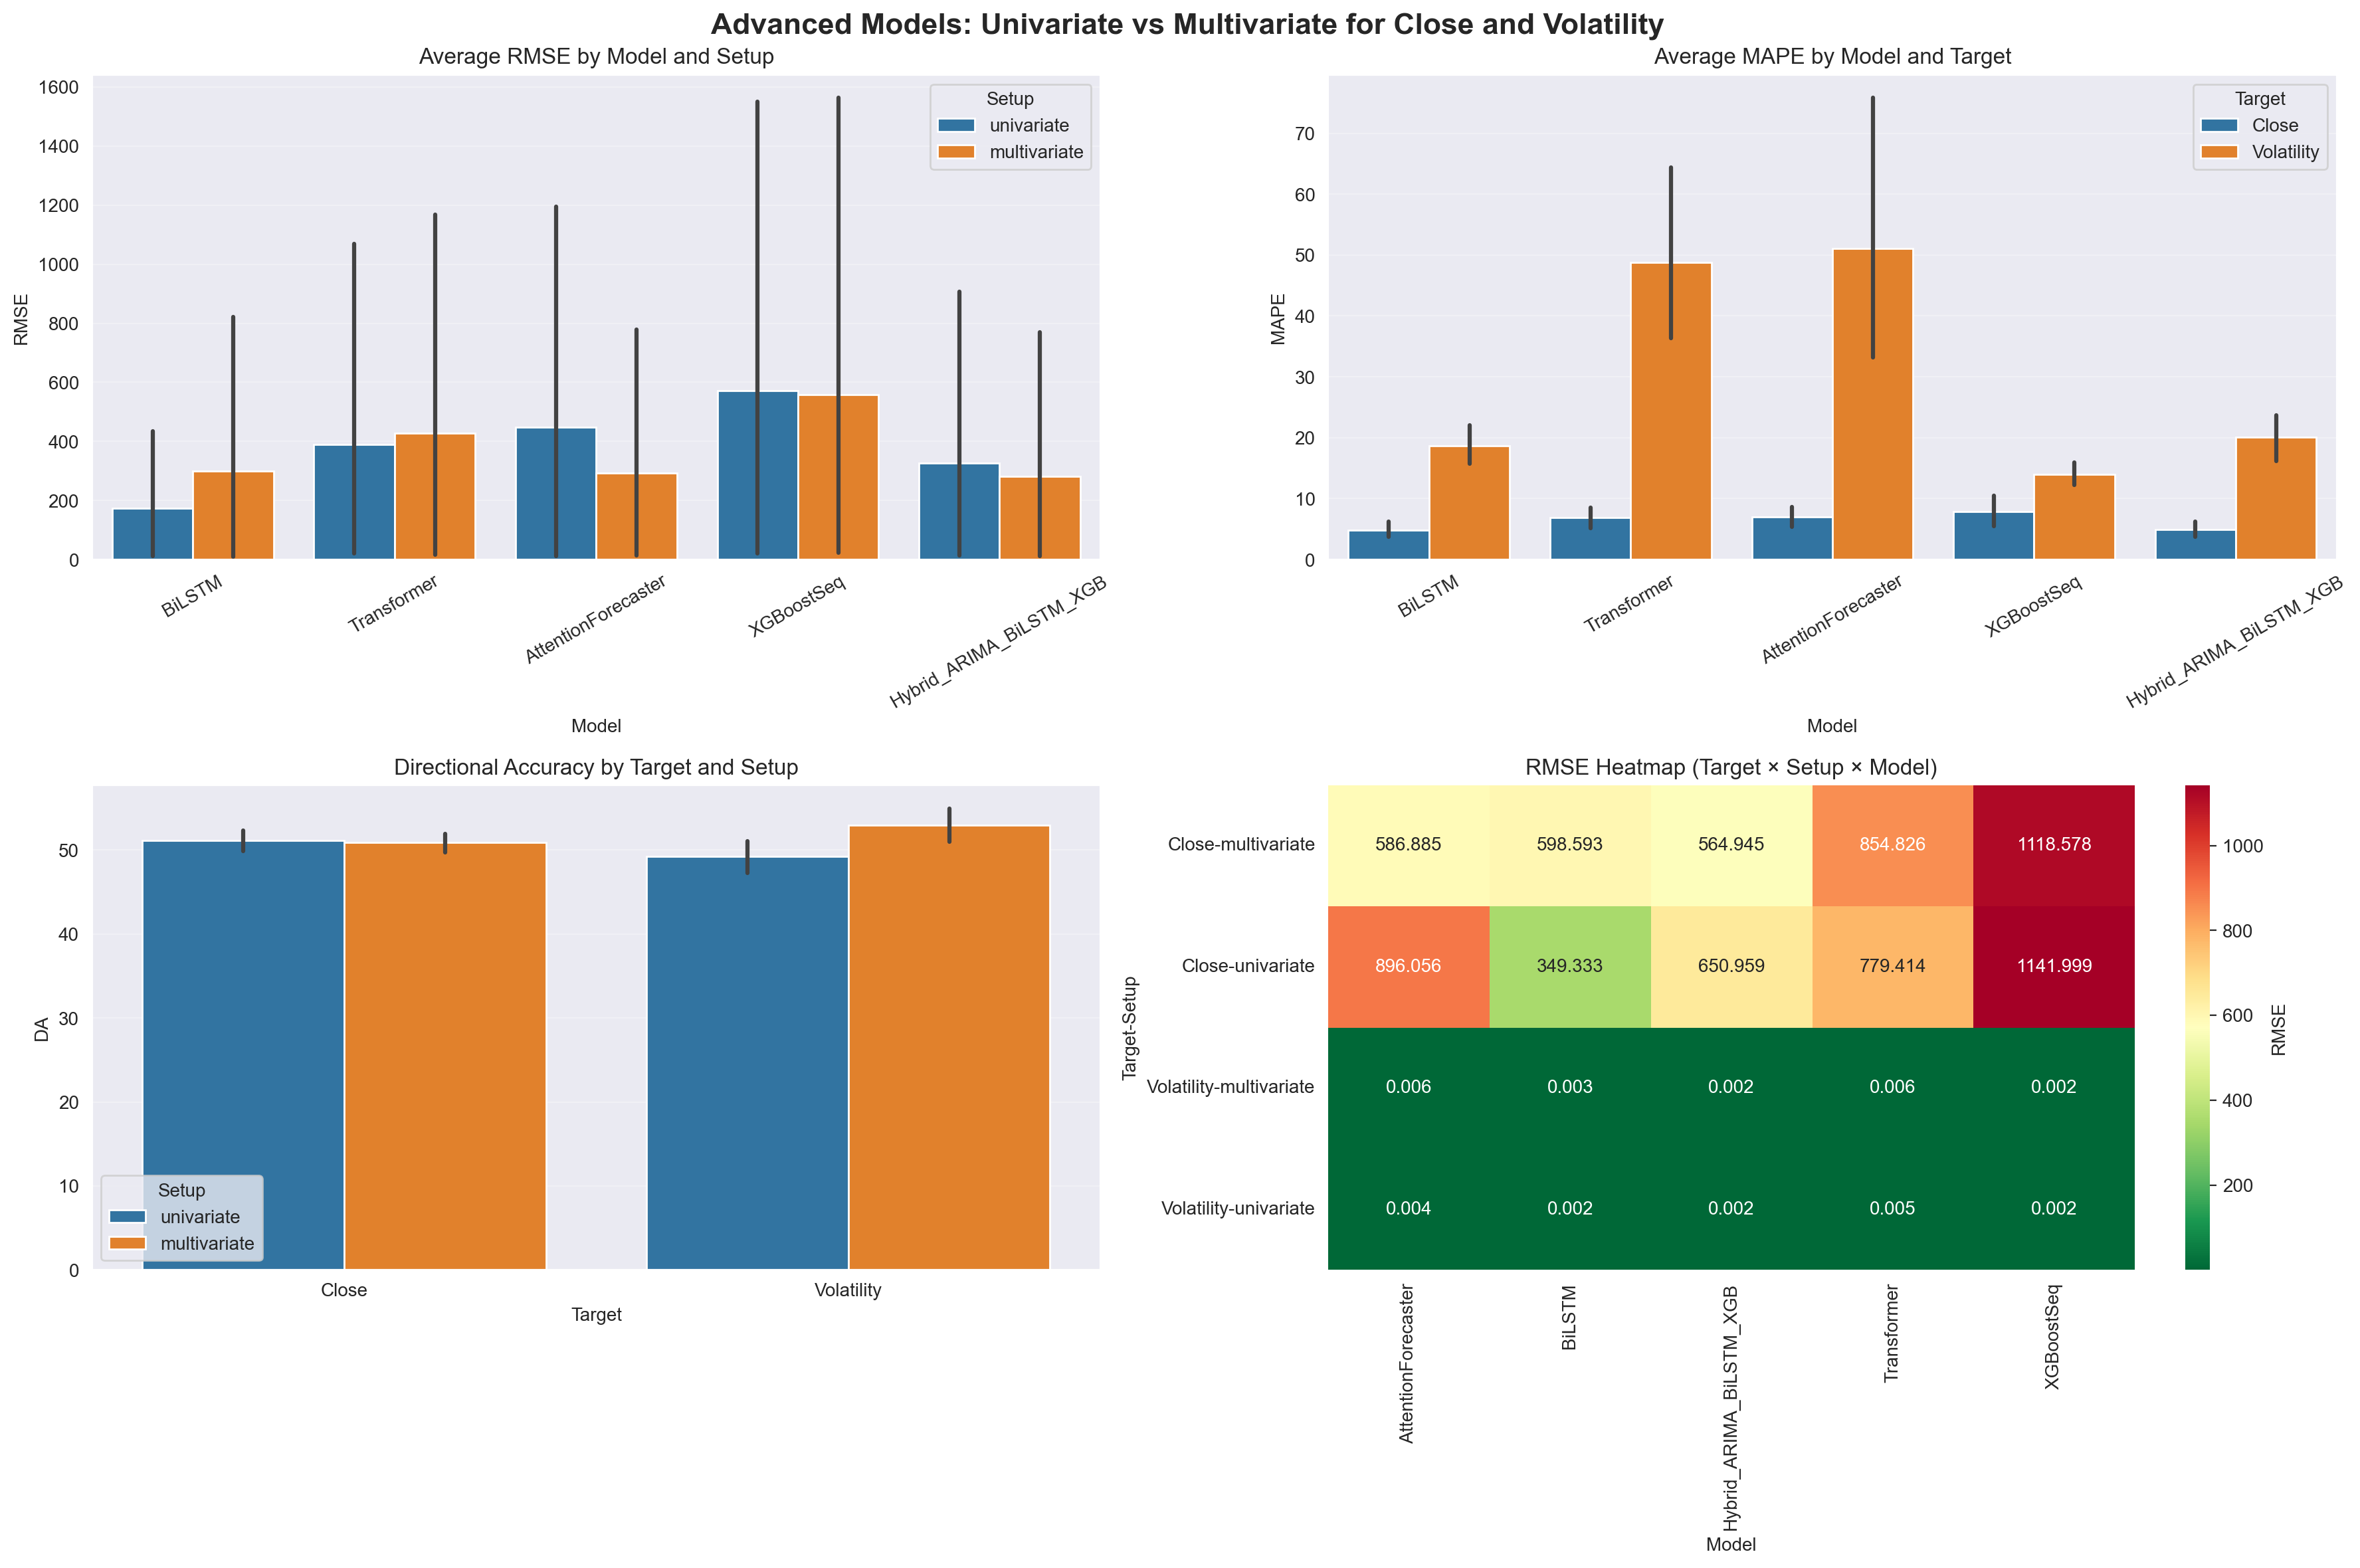


✓ Saved: study1_advanced_models_comparison.png


In [41]:
# Advanced analysis: ranking, setup impact, and plots
if len(advanced_results_df) == 0:
    print('No advanced results available for analysis.')
else:
    print('=' * 100)
    print('ADVANCED MODEL ANALYSIS: CLOSE + VOLATILITY | UNIVARIATE vs MULTIVARIATE')
    print('=' * 100)

    print('\nTop 20 configurations by RMSE:')
    top20_adv = advanced_results_df.nsmallest(20, 'RMSE')
    print(top20_adv[['Stock', 'Target', 'Setup', 'Model', 'RMSE', 'MAPE', 'DA']].to_string(index=False))

    # Aggregated model performance
    print('\n' + '-' * 100)
    print('Average performance by Model × Setup × Target')
    model_setup_target = advanced_results_df.groupby(['Target', 'Setup', 'Model'])[['RMSE', 'MAPE', 'DA']].mean().round(4)
    print(model_setup_target)

    # Setup comparison: univariate vs multivariate
    setup_cmp = advanced_results_df.groupby(['Target', 'Setup'])[['RMSE', 'MAPE', 'DA']].mean().reset_index()

    print('\n' + '-' * 100)
    print('Setup-level comparison (Univariate vs Multivariate):')
    print(setup_cmp.round(4).to_string(index=False))

    # Best setup per target
    best_setup_per_target = advanced_results_df.groupby(['Target', 'Setup'])['RMSE'].mean().reset_index()
    idx = best_setup_per_target.groupby('Target')['RMSE'].idxmin()
    best_setup_summary = best_setup_per_target.loc[idx].sort_values('Target')

    print('\nBest setup per target (by avg RMSE):')
    print(best_setup_summary.to_string(index=False))

    # Best model per target and setup
    target_setup_winner_idx = advanced_results_df.groupby(['Target', 'Setup'])['RMSE'].idxmin()
    target_setup_winners = advanced_results_df.loc[target_setup_winner_idx].sort_values(['Target', 'Setup'])

    print('\nBest model for each Target × Setup:')
    print(target_setup_winners[['Target', 'Setup', 'Stock', 'Model', 'RMSE', 'MAPE', 'DA']].to_string(index=False))

    # Visual analysis
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Advanced Models: Univariate vs Multivariate for Close and Volatility', fontsize=16, fontweight='bold')

    sns.barplot(
        data=advanced_results_df,
        x='Model', y='RMSE', hue='Setup',
        estimator=np.mean, ax=axes[0, 0]
    )
    axes[0, 0].set_title('Average RMSE by Model and Setup')
    axes[0, 0].tick_params(axis='x', rotation=30)
    axes[0, 0].grid(axis='y', alpha=0.3)

    sns.barplot(
        data=advanced_results_df,
        x='Model', y='MAPE', hue='Target',
        estimator=np.mean, ax=axes[0, 1]
    )
    axes[0, 1].set_title('Average MAPE by Model and Target')
    axes[0, 1].tick_params(axis='x', rotation=30)
    axes[0, 1].grid(axis='y', alpha=0.3)

    sns.barplot(
        data=advanced_results_df,
        x='Target', y='DA', hue='Setup',
        estimator=np.mean, ax=axes[1, 0]
    )
    axes[1, 0].set_title('Directional Accuracy by Target and Setup')
    axes[1, 0].grid(axis='y', alpha=0.3)

    heat_adv = advanced_results_df.pivot_table(
        values='RMSE',
        index=['Target', 'Setup'],
        columns='Model',
        aggfunc='mean'
    )
    sns.heatmap(heat_adv, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=axes[1, 1], cbar_kws={'label': 'RMSE'})
    axes[1, 1].set_title('RMSE Heatmap (Target × Setup × Model)')

    plt.tight_layout()
    plt.savefig('./study1_advanced_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('\n✓ Saved: study1_advanced_models_comparison.png')

In [ ]:
# Generate a concise advanced-study report and save outputs
if len(advanced_results_df) == 0:
    print('Skipping report generation because advanced_results_df is empty.')
else:
    adv_report = []
    adv_report.append('=' * 110)
    adv_report.append('STUDY 1 - ADVANCED HYBRID & ATTENTION MODEL ANALYSIS')
    adv_report.append('=' * 110)
    adv_report.append('')
    adv_report.append('Scope:')
    adv_report.append(f"- Stocks: {', '.join(sorted(stocks))}")
    adv_report.append('- Targets: Close, Volatility')
    adv_report.append('- Setups: Univariate (single column) vs Multivariate (multiple columns + engineered features)')
    adv_report.append('- Models: BiLSTM, Transformer, AttentionForecaster, XGBoostSeq, Hybrid_ARIMA_BiLSTM_XGB')
    adv_report.append(f'- Total Successful Runs: {len(advanced_results_df)}')
    adv_report.append('')

    # Global ranking
    adv_report.append('-' * 110)
    adv_report.append('TOP 15 CONFIGURATIONS (BY RMSE)')
    adv_report.append('-' * 110)
    top15 = advanced_results_df.nsmallest(15, 'RMSE')
    for i, (_, row) in enumerate(top15.iterrows(), 1):
        adv_report.append(
            f"{i:2d}. {row['Stock']:10} | {row['Target']:10} | {row['Setup']:12} | {row['Model']:26} "
            f"RMSE={row['RMSE']:.5f}, MAPE={row['MAPE']:.3f}%, DA={row['DA']:.2f}%"
        )

    # Setup effect
    setup_perf = advanced_results_df.groupby(['Target', 'Setup'])[['RMSE', 'MAPE', 'DA']].mean().round(5)
    adv_report.append('')
    adv_report.append('-' * 110)
    adv_report.append('UNIVARIATE vs MULTIVARIATE (AVERAGES)')
    adv_report.append('-' * 110)
    adv_report.append(str(setup_perf))

    # Model effect by target
    model_perf_target = advanced_results_df.groupby(['Target', 'Model'])[['RMSE', 'MAPE', 'DA']].mean().round(5)
    adv_report.append('')
    adv_report.append('-' * 110)
    adv_report.append('MODEL RANKING BY TARGET (AVERAGE METRICS)')
    adv_report.append('-' * 110)
    adv_report.append(str(model_perf_target))

    # Best model per target + setup
    winner_idx = advanced_results_df.groupby(['Target', 'Setup'])['RMSE'].idxmin()
    winners = advanced_results_df.loc[winner_idx].sort_values(['Target', 'Setup'])

    adv_report.append('')
    adv_report.append('-' * 110)
    adv_report.append('BEST MODEL PER TARGET × SETUP')
    adv_report.append('-' * 110)
    for _, row in winners.iterrows():
        adv_report.append(
            f"- {row['Target']:10} | {row['Setup']:12} -> {row['Model']:26} "
            f"({row['Stock']}) RMSE={row['RMSE']:.5f}, MAPE={row['MAPE']:.3f}%, DA={row['DA']:.2f}%"
        )

    # Narrative insights
    adv_report.append('')
    adv_report.append('-' * 110)
    adv_report.append('INTERPRETATION')
    adv_report.append('-' * 110)

    for target in ['Close', 'Volatility']:
        d = advanced_results_df[advanced_results_df['Target'] == target]
        uni_rmse = d[d['Setup'] == 'univariate']['RMSE'].mean()
        multi_rmse = d[d['Setup'] == 'multivariate']['RMSE'].mean()

        if pd.notna(uni_rmse) and pd.notna(multi_rmse):
            delta = uni_rmse - multi_rmse
            if delta > 0:
                adv_report.append(f"- {target}: Multivariate improves RMSE by {delta:.5f} on average versus univariate.")
            else:
                adv_report.append(f"- {target}: Univariate is better by {abs(delta):.5f} RMSE on average (possible overfitting/noisy exogenous effects).")

        best_model_target = d.groupby('Model')['RMSE'].mean().idxmin()
        best_model_rmse = d.groupby('Model')['RMSE'].mean().min()
        adv_report.append(f"  Best average model for {target}: {best_model_target} (RMSE={best_model_rmse:.5f}).")

    adv_report.append('')
    adv_report.append('=' * 110)

    adv_text = '\n'.join(adv_report)
    print(adv_text)

    # Save files
    adv_report_path = '/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_advanced_hybrid_analysis_report.txt'
    with open(adv_report_path, 'w') as f:
        f.write(adv_text)

    advanced_csv_path = '/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_advanced_model_results.csv'
    advanced_results_df.to_csv(advanced_csv_path, index=False)

    # Optional merge with existing results for unified downstream analysis
    merged_view = advanced_results_df.rename(columns={'Target': 'Column'}).copy()
    merged_view['Decomposition'] = 'advanced_seq_setup'

    combined_path = '/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_combined_classical_advanced_results.csv'
    combined_results_df = pd.concat([
        results_df[['Stock', 'Column', 'Decomposition', 'Model', 'MAE', 'RMSE', 'MAPE', 'DA']].copy(),
        merged_view[['Stock', 'Column', 'Decomposition', 'Model', 'MAE', 'RMSE', 'MAPE', 'DA']].copy()
    ], ignore_index=True)
    combined_results_df.to_csv(combined_path, index=False)

    print(f"\n✓ Saved advanced report: {adv_report_path}")
    print(f"✓ Saved advanced results CSV: {advanced_csv_path}")
    print(f"✓ Saved combined classical+advanced CSV: {combined_path}")

STUDY 1 - ADVANCED HYBRID & ATTENTION MODEL ANALYSIS

Scope:
- Stocks: HDFCBANK, NIFTY50, RELIANCE, TCS
- Targets: Close, Volatility
- Setups: Univariate (single column) vs Multivariate (multiple columns + engineered features)
- Models: BiLSTM, Transformer, AttentionForecaster, XGBoostSeq, Hybrid_ARIMA_BiLSTM_XGB
- Total Successful Runs: 80

--------------------------------------------------------------------------------------------------------------
TOP 15 CONFIGURATIONS (BY RMSE)
--------------------------------------------------------------------------------------------------------------
 1. NIFTY50    | Volatility | multivariate | XGBoostSeq                 RMSE=0.00113, MAPE=11.596%, DA=58.24%
 2. NIFTY50    | Volatility | univariate   | XGBoostSeq                 RMSE=0.00143, MAPE=12.972%, DA=52.25%
 3. TCS        | Volatility | univariate   | XGBoostSeq                 RMSE=0.00160, MAPE=10.126%, DA=52.24%
 4. NIFTY50    | Volatility | multivariate | Hybrid_ARIMA_BiLSTM_XGB    

## 9. Stock-Wise Detailed Analysis

In [ ]:
# Stock-wise performance analysis
stock_analysis = {}

for stock in stocks:
    stock_results = results_df[results_df['Stock'] == stock]
    
    stock_analysis[stock] = {
        'n_combinations': len(stock_results),
        'avg_rmse': stock_results['RMSE'].mean(),
        'min_rmse': stock_results['RMSE'].min(),
        'max_rmse': stock_results['RMSE'].max(),
        'std_rmse': stock_results['RMSE'].std(),
        'avg_mape': stock_results['MAPE'].mean(),
        'avg_da': stock_results['DA'].mean(),
        'best_model': stock_results.loc[stock_results['RMSE'].idxmin()]['Model'],
        'best_column': stock_results.loc[stock_results['RMSE'].idxmin()]['Column'],
        'best_decomp': stock_results.loc[stock_results['RMSE'].idxmin()]['Decomposition']
    }

print("="*100)
print("STOCK-WISE PERFORMANCE SUMMARY")
print("="*100)
print(f"\n{'Stock':<15} {'Combinations':<15} {'Avg RMSE':<15} {'Min RMSE':<15} {'Avg MAPE':<15} {'Avg DA':<10}")
print("-"*100)
for stock, stats in sorted(stock_analysis.items()):
    print(f"{stock:<15} {stats['n_combinations']:<15} {stats['avg_rmse']:<15.4f} {stats['min_rmse']:<15.4f} {stats['avg_mape']:<15.2f} {stats['avg_da']:<10.2f}%")

print("\n" + "="*100)
print("BEST MODELS BY STOCK")
print("="*100)
for stock, stats in sorted(stock_analysis.items()):
    print(f"\n{stock}:")
    print(f"  Best Model: {stats['best_model']}")
    print(f"  Best Target: {stats['best_column']}")
    print(f"  Best Decomposition: {stats['best_decomp']}")
    print(f"  Avg RMSE: {stats['avg_rmse']:.4f} (Min: {stats['min_rmse']:.4f})")
    print(f"  Avg MAPE: {stats['avg_mape']:.2f}%")
    print(f"  Avg Directional Accuracy: {stats['avg_da']:.2f}%")

STOCK-WISE PERFORMANCE SUMMARY

Stock           Combinations    Avg RMSE        Min RMSE        Avg MAPE        Avg DA    
----------------------------------------------------------------------------------------------------
HDFCBANK        80              35.3086         0.0017          8.54            53.55     %
NIFTY50         80              2256.3108       0.0010          14.80           52.44     %
RELIANCE        80              95.0730         0.0012          10.55           53.48     %
TCS             80              294.0955        0.0011          11.20           51.53     %

BEST MODELS BY STOCK

HDFCBANK:
  Best Model: XGBoost
  Best Target: Volatility
  Best Decomposition: original
  Avg RMSE: 35.3086 (Min: 0.0017)
  Avg MAPE: 8.54%
  Avg Directional Accuracy: 53.55%

NIFTY50:
  Best Model: RandomForest
  Best Target: Volatility
  Best Decomposition: original
  Avg RMSE: 2256.3108 (Min: 0.0010)
  Avg MAPE: 14.80%
  Avg Directional Accuracy: 52.44%

RELIANCE:
  Best Model: 

In [ ]:
# Detailed analysis per stock
print("\n" + "="*100)
print("DETAILED STOCK-WISE ANALYSIS")
print("="*100)

for stock in stocks:
    stock_data = results_df[results_df['Stock'] == stock]
    print(f"\n{'='*100}")
    print(f"STOCK: {stock}")
    print(f"{'='*100}")
    print(f"Total Test Cases: {len(stock_data)}")
    
    # Best 5 models for this stock
    print(f"\nTop 5 Best Models for {stock}:")
    best_5 = stock_data.nsmallest(5, 'RMSE')[['Column', 'Decomposition', 'Model', 'RMSE', 'MAPE', 'DA']]
    for idx, (i, row) in enumerate(best_5.iterrows(), 1):
        print(f"  {idx}. {row['Model']:15} on {row['Column']:12} ({row['Decomposition']:20}) → RMSE: {row['RMSE']:8.4f}, MAPE: {row['MAPE']:6.2f}%, DA: {row['DA']:5.1f}%")
    
    # Performance by model type
    print(f"\nModel Performance Summary for {stock}:")
    model_perf = stock_data.groupby('Model')[['RMSE', 'MAPE', 'DA']].agg(['mean', 'std']).round(4)
    for model in stock_data['Model'].unique():
        model_data = stock_data[stock_data['Model'] == model]
        print(f"  {model:15}: Avg RMSE: {model_data['RMSE'].mean():8.4f}, Avg MAPE: {model_data['MAPE'].mean():6.2f}%, Avg DA: {model_data['DA'].mean():5.1f}%")
    
    # Performance by column
    print(f"\nTarget Column Performance for {stock}:")
    for col in forecast_columns_subset:
        col_data = stock_data[stock_data['Column'] == col]
        if len(col_data) > 0:
            print(f"  {col:12}: Avg RMSE: {col_data['RMSE'].mean():8.4f}, Avg MAPE: {col_data['MAPE'].mean():6.2f}%")
    
    # Decomposition impact
    print(f"\nDecomposition Method Performance for {stock}:")
    for decomp in stock_data['Decomposition'].unique():
        decomp_data = stock_data[stock_data['Decomposition'] == decomp]
        print(f"  {decomp:25}: Avg RMSE: {decomp_data['RMSE'].mean():8.4f}, Avg MAPE: {decomp_data['MAPE'].mean():6.2f}%")


DETAILED STOCK-WISE ANALYSIS

STOCK: HDFCBANK
Total Test Cases: 80

Top 5 Best Models for HDFCBANK:
  1. XGBoost         on Volatility   (original            ) → RMSE:   0.0017, MAPE:   9.74%, DA:  63.3%
  2. XGBoost         on Volatility   (classical_additive  ) → RMSE:   0.0017, MAPE:   9.74%, DA:  63.3%
  3. XGBoost         on Volatility   (classical_multiplicative) → RMSE:   0.0017, MAPE:   9.74%, DA:  63.3%
  4. XGBoost         on Volatility   (stl                 ) → RMSE:   0.0017, MAPE:   9.74%, DA:  63.3%
  5. RandomForest    on Volatility   (classical_additive  ) → RMSE:   0.0020, MAPE:  10.62%, DA:  62.8%

Model Performance Summary for HDFCBANK:
  ARIMA          : Avg RMSE:  38.3027, Avg MAPE:  11.59%, Avg DA:  48.6%
  ExpSmoothing   : Avg RMSE:  63.0947, Avg MAPE:  14.77%, Avg DA:  52.9%
  LSTM           : Avg RMSE:  17.9488, Avg MAPE:   7.00%, Avg DA:  52.6%
  XGBoost        : Avg RMSE:  29.5448, Avg MAPE:   4.67%, Avg DA:  56.7%
  RandomForest   : Avg RMSE:  27.6521, Avg

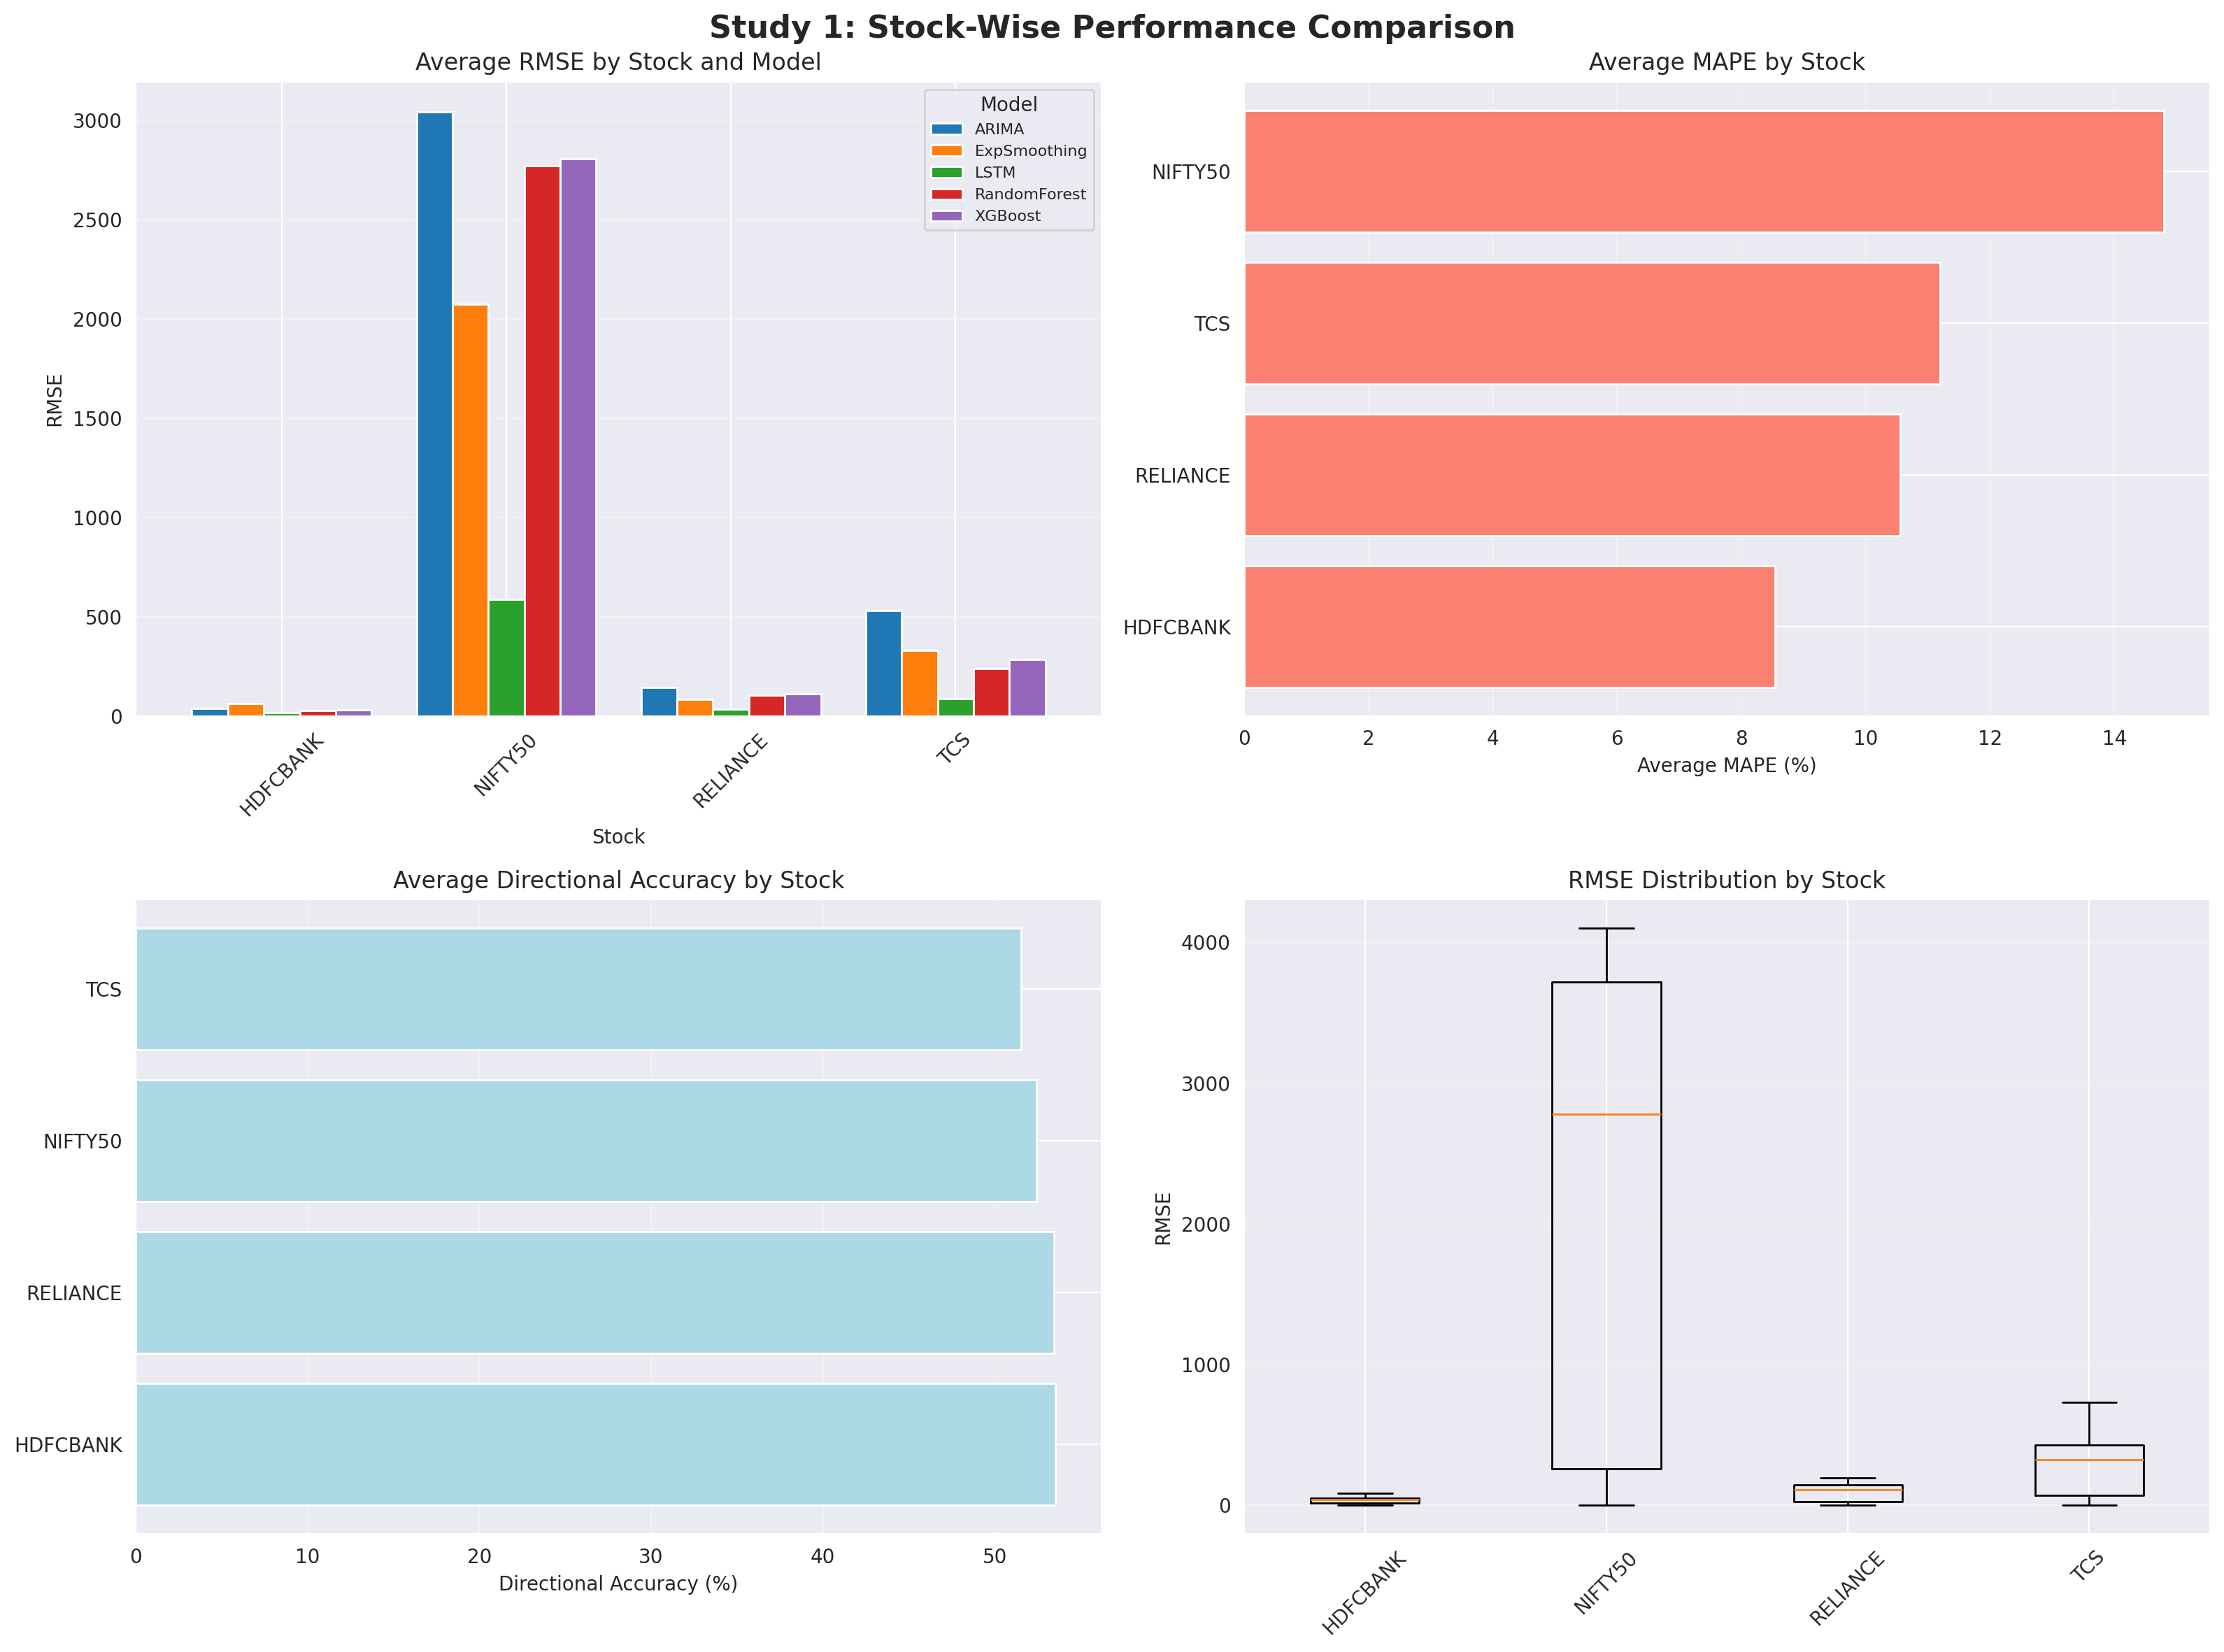

✓ Saved: study1_stock_wise_comparison.png


In [ ]:
# Stock-wise comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Study 1: Stock-Wise Performance Comparison', fontsize=16, fontweight='bold')

# 1. Average RMSE by Stock and Model
stock_model_rmse = results_df.pivot_table(values='RMSE', index='Stock', columns='Model', aggfunc='mean')
stock_model_rmse.plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Average RMSE by Stock and Model')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_xlabel('Stock')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend(title='Model', fontsize=8)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Average MAPE by Stock
stock_mape = results_df.groupby('Stock')['MAPE'].mean().sort_values()
axes[0, 1].barh(stock_mape.index, stock_mape.values, color='salmon')
axes[0, 1].set_xlabel('Average MAPE (%)')
axes[0, 1].set_title('Average MAPE by Stock')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Average Directional Accuracy by Stock
stock_da = results_df.groupby('Stock')['DA'].mean().sort_values(ascending=False)
axes[1, 0].barh(stock_da.index, stock_da.values, color='lightblue')
axes[1, 0].set_xlabel('Directional Accuracy (%)')
axes[1, 0].set_title('Average Directional Accuracy by Stock')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. RMSE Distribution by Stock (box plot)
stock_list = sorted(results_df['Stock'].unique())
rmse_data = [results_df[results_df['Stock'] == stock]['RMSE'].values for stock in stock_list]
axes[1, 1].boxplot(rmse_data, labels=stock_list)
axes[1, 1].set_ylabel('RMSE')
axes[1, 1].set_title('RMSE Distribution by Stock')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_stock_wise_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: study1_stock_wise_comparison.png")

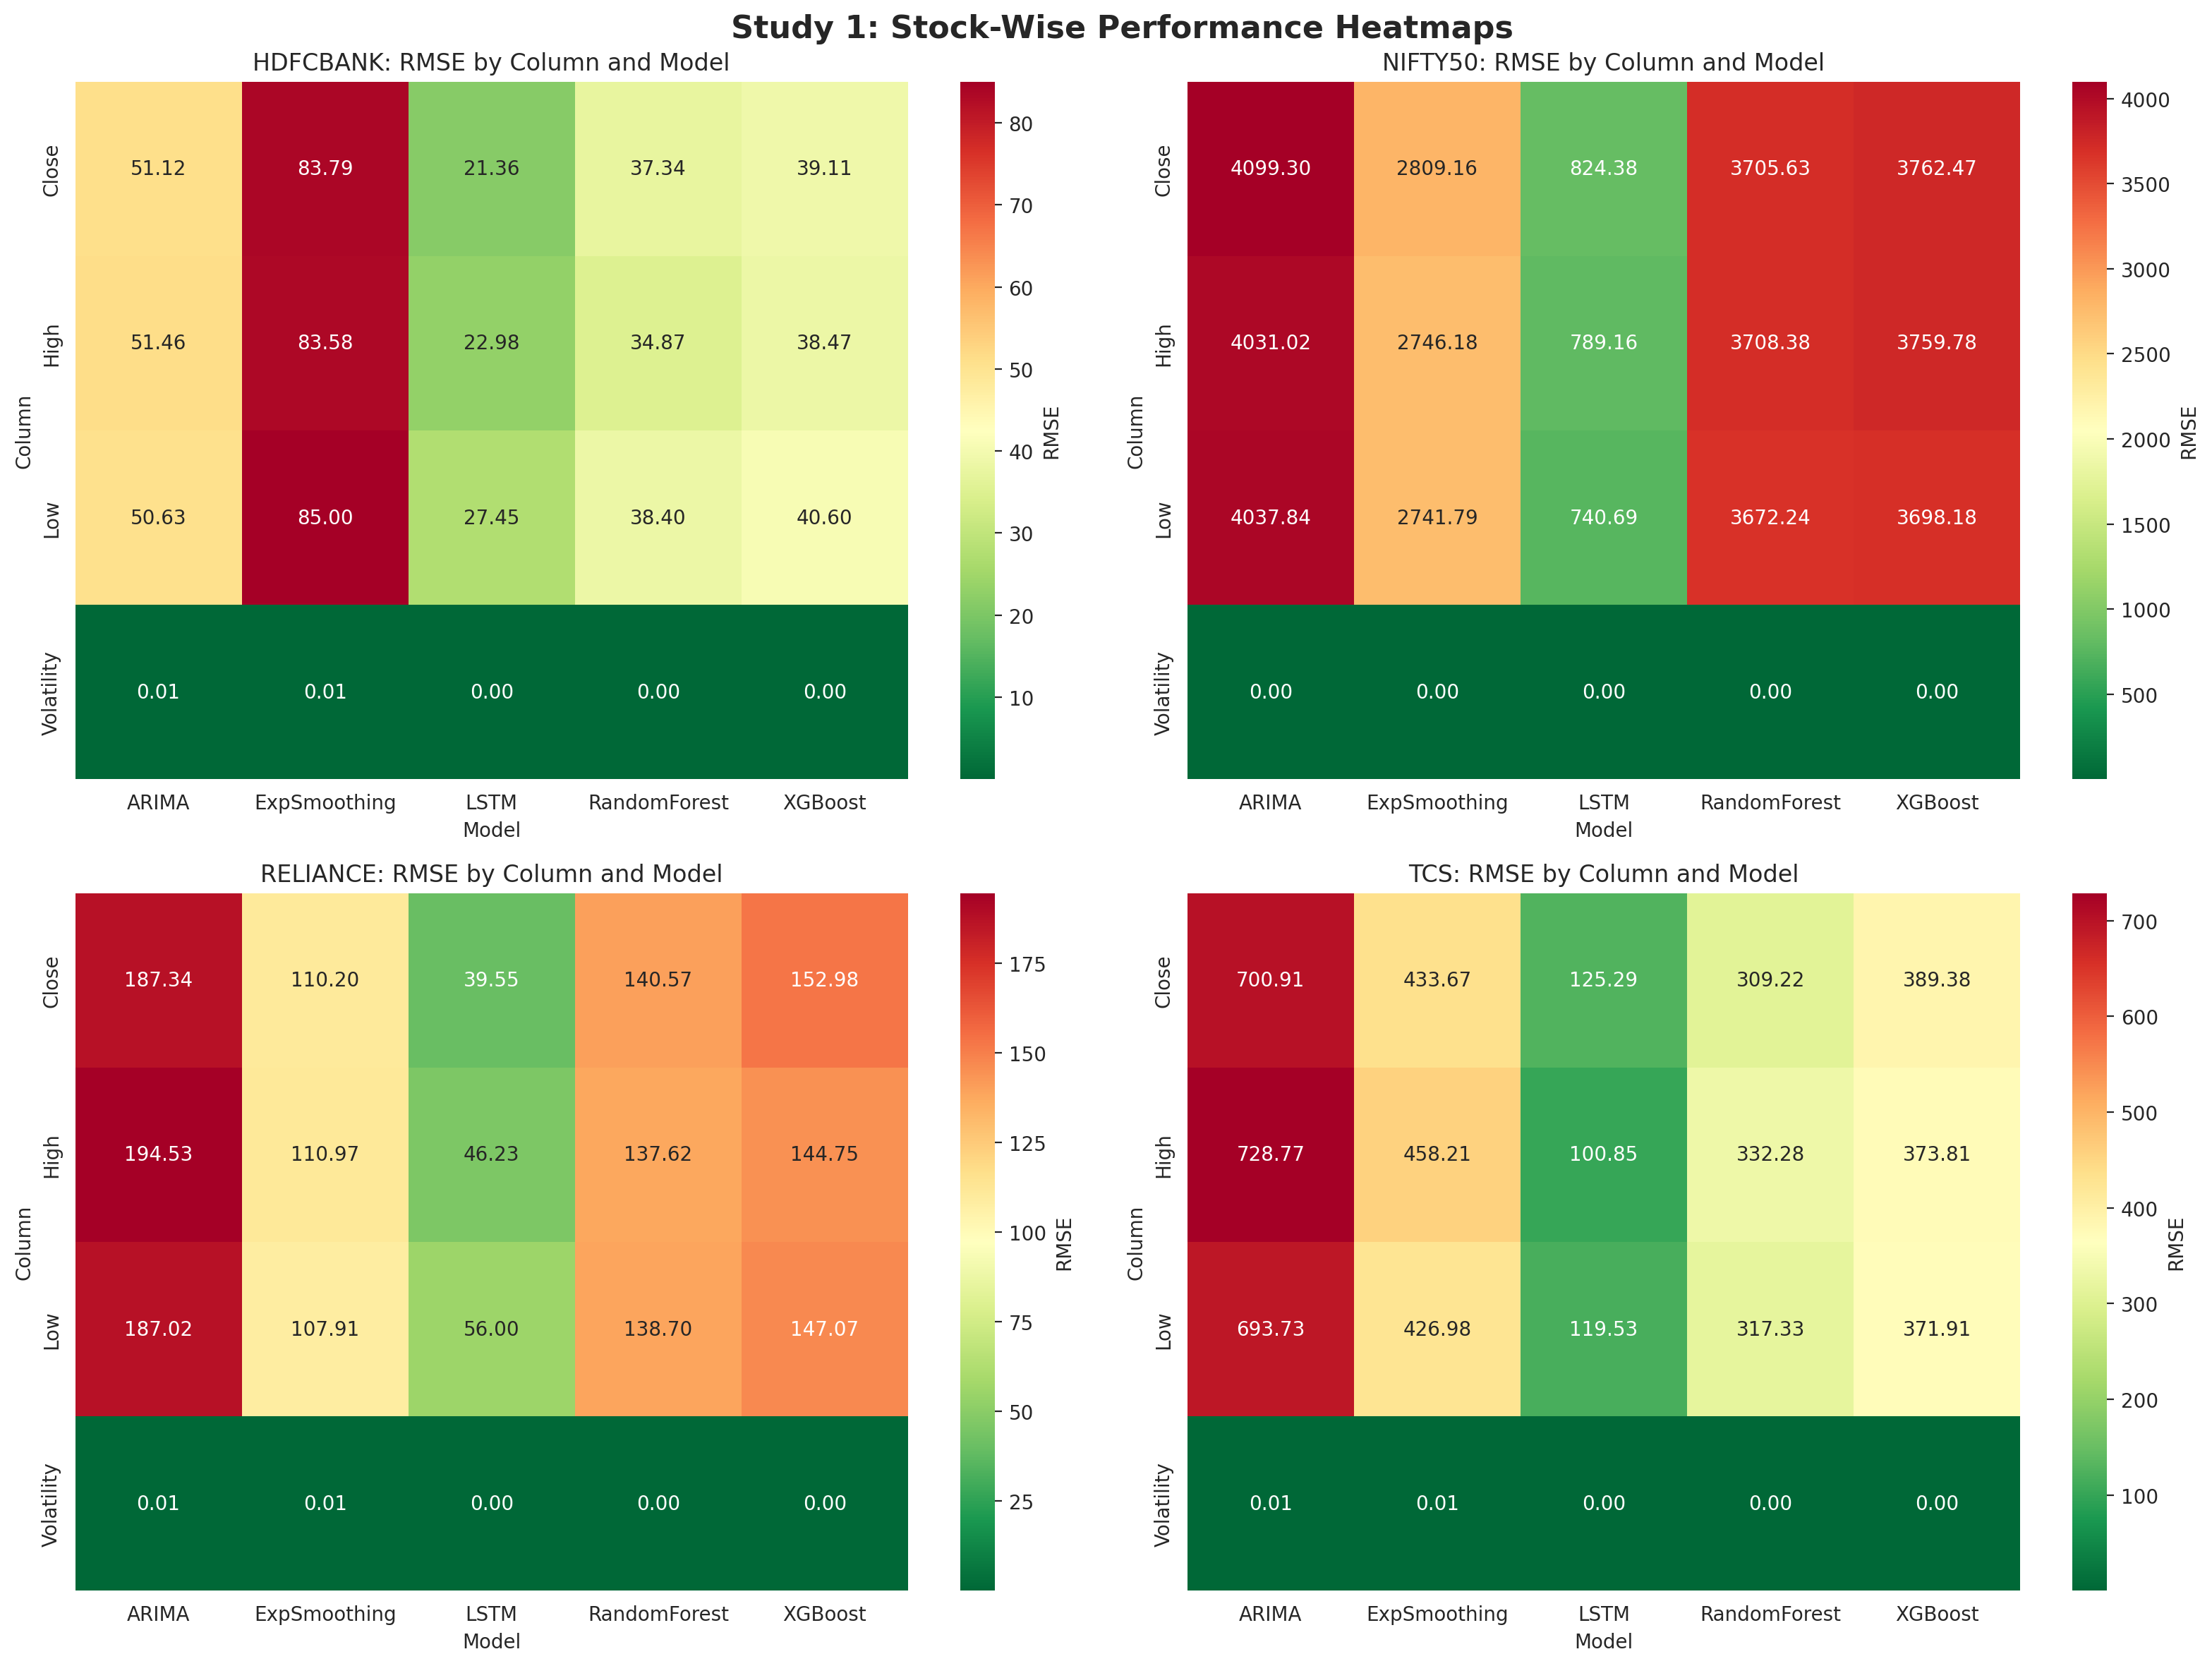

✓ Saved: study1_stock_wise_heatmaps.png


In [ ]:
# Stock and Column combination heatmap
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Study 1: Stock-Wise Performance Heatmaps', fontsize=16, fontweight='bold')

col_idx = 0
for stock in sorted(stocks):
    stock_data = results_df[results_df['Stock'] == stock]
    
    # Create pivot table for this stock
    heatmap_data = stock_data.pivot_table(
        values='RMSE',
        index='Column',
        columns='Model',
        aggfunc='mean'
    )
    
    row, col = col_idx // 2, col_idx % 2
    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[row, col], cbar_kws={'label': 'RMSE'})
    axes[row, col].set_title(f'{stock}: RMSE by Column and Model')
    col_idx += 1

plt.tight_layout()
plt.savefig('/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_stock_wise_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: study1_stock_wise_heatmaps.png")

In [ ]:
# Generate comprehensive stock-wise report
stock_report = f"""
{'='*120}
STUDY 1: COMPREHENSIVE STOCK-WISE ANALYSIS REPORT
{'='*120}

EXPERIMENT CONFIGURATION:
- Total Stocks Analyzed: {len(stocks)}
- Forecast Targets per Stock: {len(forecast_columns_subset)}
- Decomposition Methods: {len(decomposition_types)}
- Forecasting Models: {len(model_types)}
- Total Combinations per Stock: {len(decomposition_types) * len(model_types) * len(forecast_columns_subset)}

"""

# Stock-wise detailed analysis
for stock in sorted(stocks):
    stock_data = results_df[results_df['Stock'] == stock]
    
    best_overall = stock_data.nsmallest(1, 'RMSE').iloc[0]
    
    stock_report += f"""
{'─'*120}
STOCK: {stock}
{'─'*120}

OVERVIEW:
  - Total Test Cases: {len(stock_data)}
  - Average RMSE: {stock_data['RMSE'].mean():.6f}
  - Best RMSE: {stock_data['RMSE'].min():.6f}
  - Worst RMSE: {stock_data['RMSE'].max():.6f}
  - RMSE Std Dev: {stock_data['RMSE'].std():.6f}
  - Average MAPE: {stock_data['MAPE'].mean():.3f}%
  - Average Directional Accuracy: {stock_data['DA'].mean():.2f}%

BEST OVERALL CONFIGURATION:
  - Model: {best_overall['Model']}
  - Target Column: {best_overall['Column']}
  - Decomposition Method: {best_overall['Decomposition']}
  - RMSE: {best_overall['RMSE']:.6f}
  - MAPE: {best_overall['MAPE']:.3f}%
  - Directional Accuracy: {best_overall['DA']:.2f}%

MODEL PERFORMANCE RANKING (by average RMSE):
"""
    
    model_perf = stock_data.groupby('Model')['RMSE'].mean().sort_values()
    for rank, (model, rmse) in enumerate(model_perf.items(), 1):
        model_data = stock_data[stock_data['Model'] == model]
        mape = model_data['MAPE'].mean()
        da = model_data['DA'].mean()
        stock_report += f"  {rank}. {model:15} → Avg RMSE: {rmse:8.6f}, Avg MAPE: {mape:6.3f}%, Avg DA: {da:5.2f}%\n"
    
    stock_report += f"""
TARGET COLUMN PERFORMANCE (by average RMSE):
"""
    col_perf = stock_data.groupby('Column')['RMSE'].mean().sort_values()
    for rank, (col, rmse) in enumerate(col_perf.items(), 1):
        col_data = stock_data[stock_data['Column'] == col]
        mape = col_data['MAPE'].mean()
        stock_report += f"  {rank}. {col:12} → Avg RMSE: {rmse:8.6f}, Avg MAPE: {mape:6.3f}%\n"
    
    stock_report += f"""
DECOMPOSITION METHOD ANALYSIS:
"""
    decomp_perf = stock_data.groupby('Decomposition')['RMSE'].mean().sort_values()
    for rank, (decomp, rmse) in enumerate(decomp_perf.items(), 1):
        decomp_data = stock_data[stock_data['Decomposition'] == decomp]
        mape = decomp_data['MAPE'].mean()
        stock_report += f"  {rank}. {decomp:25} → Avg RMSE: {rmse:8.6f}, Avg MAPE: {mape:6.3f}%\n"

# Overall comparison
stock_report += f"""

{'='*120}
STOCK COMPARISON SUMMARY
{'='*120}

Ranking by Average RMSE (Lower is Better):
"""

stock_ranking = results_df.groupby('Stock')['RMSE'].mean().sort_values()
for rank, (stock, rmse) in enumerate(stock_ranking.items(), 1):
    stock_data = results_df[results_df['Stock'] == stock]
    mape = stock_data['MAPE'].mean()
    da = stock_data['DA'].mean()
    stock_report += f"{rank}. {stock:12} → Avg RMSE: {rmse:8.6f}, Avg MAPE: {mape:6.3f}%, Avg DA: {da:5.2f}%\n"

stock_report += f"""

Ranking by Directional Accuracy (Higher is Better):
"""

stock_da_ranking = results_df.groupby('Stock')['DA'].mean().sort_values(ascending=False)
for rank, (stock, da) in enumerate(stock_da_ranking.items(), 1):
    stock_data = results_df[results_df['Stock'] == stock]
    rmse = stock_data['RMSE'].mean()
    mape = stock_data['MAPE'].mean()
    stock_report += f"{rank}. {stock:12} → Avg DA: {da:5.2f}%, Avg RMSE: {rmse:8.6f}, Avg MAPE: {mape:6.3f}%\n"

stock_report += f"""

{'='*120}
KEY INSIGHTS & RECOMMENDATIONS
{'='*120}

1. STOCK DIFFICULTY RANKING (by RMSE):
   - Easiest to Forecast: {stock_ranking.index[0]} (RMSE: {stock_ranking.values[0]:.6f})
   - Most Difficult: {stock_ranking.index[-1]} (RMSE: {stock_ranking.values[-1]:.6f})

2. BEST DIRECTIONAL PREDICTOR:
   - Stock: {stock_da_ranking.index[0]} (DA: {stock_da_ranking.values[0]:.2f}%)

3. RECOMMENDED MODELS BY STOCK:
"""

for stock in sorted(stocks):
    stock_data = results_df[results_df['Stock'] == stock]
    best = stock_data.nsmallest(1, 'RMSE').iloc[0]
    stock_report += f"   - {stock:12}: Use {best['Model']:15} on {best['Column']:12} (RMSE: {best['RMSE']:.6f})\n"

stock_report += f"""

4. FORECAST COLUMN DIFFICULTY:
"""
col_ranking = results_df.groupby('Column')['RMSE'].mean().sort_values()
for rank, (col, rmse) in enumerate(col_ranking.items(), 1):
    col_data = results_df[results_df['Column'] == col]
    stock_report += f"   {rank}. {col:12} → Avg RMSE: {rmse:8.4f}\n"

stock_report += f"""

5. OVERALL MODEL EFFECTIVENESS:
"""
model_ranking = results_df.groupby('Model')['RMSE'].mean().sort_values()
for rank, (model, rmse) in enumerate(model_ranking.items(), 1):
    model_data = results_df[results_df['Model'] == model]
    da = model_data['DA'].mean()
    stock_report += f"   {rank}. {model:15} → Avg RMSE: {rmse:8.4f}, Avg DA: {da:5.2f}%\n"

stock_report += f"\n{'='*120}\n"

print(stock_report)

# Save comprehensive stock report
report_path = "/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_stock_wise_analysis_report.txt"
with open(report_path, 'w') as f:
    f.write(stock_report)
print(f"✓ Stock-wise analysis report saved: {report_path}")


STUDY 1: COMPREHENSIVE STOCK-WISE ANALYSIS REPORT

EXPERIMENT CONFIGURATION:
- Total Stocks Analyzed: 4
- Forecast Targets per Stock: 4
- Decomposition Methods: 4
- Forecasting Models: 5
- Total Combinations per Stock: 80


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
STOCK: HDFCBANK
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

OVERVIEW:
  - Total Test Cases: 80
  - Average RMSE: 35.308610
  - Best RMSE: 0.001702
  - Worst RMSE: 85.004239
  - RMSE Std Dev: 27.255233
  - Average MAPE: 8.545%
  - Average Directional Accuracy: 53.55%

BEST OVERALL CONFIGURATION:
  - Model: XGBoost
  - Target Column: Volatility
  - Decomposition Method: original
  - RMSE: 0.001702
  - MAPE: 9.739%
  - Directional Accuracy: 63.26%

MODEL PERFORMANCE RANKING (by average RMSE):
  1. LSTM            → Avg RMSE: 17.948806, Avg MAPE:  6.996%, Avg DA: 52.64%
  2

In [ ]:
# Create stock-wise Excel report with detailed analysis
stock_excel_path = "/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_stock_wise_analysis.xlsx"

with pd.ExcelWriter(stock_excel_path, engine='openpyxl') as writer:
    # Summary sheet
    summary_data = []
    for stock in sorted(stocks):
        stock_data = results_df[results_df['Stock'] == stock]
        best = stock_data.nsmallest(1, 'RMSE').iloc[0]
        summary_data.append({
            'Stock': stock,
            'Num_Tests': len(stock_data),
            'Avg_RMSE': stock_data['RMSE'].mean(),
            'Min_RMSE': stock_data['RMSE'].min(),
            'Max_RMSE': stock_data['RMSE'].max(),
            'Avg_MAPE': stock_data['MAPE'].mean(),
            'Avg_DA': stock_data['DA'].mean(),
            'Best_Model': best['Model'],
            'Best_Column': best['Column'],
            'Best_Decomposition': best['Decomposition'],
            'Best_RMSE': best['RMSE'],
            'Best_MAPE': best['MAPE']
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_excel(writer, sheet_name='Stock Summary', index=False)
    
    # Individual stock analysis sheets
    for stock in sorted(stocks):
        stock_data = results_df[results_df['Stock'] == stock]
        
        # Best configurations
        best_configs = stock_data.nsmallest(10, 'RMSE')[['Column', 'Decomposition', 'Model', 'RMSE', 'MAPE', 'DA']]
        best_configs.to_excel(writer, sheet_name=f'{stock}_Top10', index=False)
    
    # Model performance comparison across stocks
    model_stock_perf = results_df.pivot_table(
        values='RMSE',
        index='Stock',
        columns='Model',
        aggfunc='mean'
    )
    model_stock_perf.to_excel(writer, sheet_name='Model Comparison')
    
    # Column performance across stocks
    col_stock_perf = results_df.pivot_table(
        values='RMSE',
        index='Stock',
        columns='Column',
        aggfunc='mean'
    )
    col_stock_perf.to_excel(writer, sheet_name='Column Comparison')

print(f"✓ Stock-wise analysis saved: {stock_excel_path}")

# Create a stock-specific CSV files
for stock in sorted(stocks):
    stock_data = results_df[results_df['Stock'] == stock].sort_values('RMSE')
    csv_path = f"/home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_{stock}_results.csv"
    stock_data.to_csv(csv_path, index=False)
    print(f"  ✓ {stock} results: {csv_path}")

✓ Stock-wise analysis saved: /home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_stock_wise_analysis.xlsx
  ✓ HDFCBANK results: /home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_HDFCBANK_results.csv
  ✓ NIFTY50 results: /home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_NIFTY50_results.csv
  ✓ RELIANCE results: /home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_RELIANCE_results.csv
  ✓ TCS results: /home/chandravesh/Desktop/time_series_forecasting_hybrid_models/study1_TCS_results.csv
